# SAR Oil Spill Detector (EfficientNet-B0)
Run the cells **from top to bottom, one at a time**: click a cell, then press the ▶ button on its left (or Shift+Enter). Wait for the green tick / finished output before running the next one.

If Colab disconnects, everything in `/content` is erased: just run again from Cell 1.

## Cell 1: Install libraries and verify the T4 GPU

In [ ]:
# Install (or upgrade) the Kaggle library so we can download datasets from Kaggle ("!" means: run this as a terminal command)
!pip install -q -U kaggle
# Import PyTorch, the main deep-learning framework we will use
import torch
# Import torchvision, PyTorch's add-on library for images and ready-made vision models
import torchvision
# Print the PyTorch version to prove the library loaded correctly
print("PyTorch version     :", torch.__version__)
# Print the torchvision version
print("torchvision version :", torchvision.__version__)
# Ask PyTorch "is a GPU available?" (gives True or False) and store the answer
gpu_ok = torch.cuda.is_available()
# Print whether a GPU is available
print("GPU available       :", gpu_ok)
# If a GPU exists print its name, otherwise print instructions for turning it on
print("GPU name            :", torch.cuda.get_device_name(0) if gpu_ok else "NONE -> Runtime > Change runtime type > T4 GPU > Save")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 4.7 MB/s eta 0:00:00
PyTorch version     : 2.11.0+cpu
torchvision version : 0.26.0+cpu
GPU available       : False
GPU name            : NONE -> Runtime > Change runtime type > T4 GPU > Save


## Cell 2: Give Colab your Kaggle key
Kaggle may give you EITHER a file called `kaggle.json` OR a long text token starting with `KGAT_`. Set `USE_JSON_FILE` below to match what you got.

In [ ]:
# Import os for folders and shutil for copying files
import os, shutil
# The folder where our clean, sorted dataset will be built
DATA_DIR = "/content/data"
# The folder that holds Class_0 and Class_1
RAW_DIR = "/content/raw/kaggle/data"
# ASSUMPTION: Class_1 is oil. If Step 3 shows this is wrong, swap these two names and rerun
OIL_FOLDER = "Class_1"
# The folder we assume holds clean ocean images
CLEAN_FOLDER = "Class_0"
# Delete any old sorted copy so re-running is always safe
shutil.rmtree(DATA_DIR, ignore_errors=True)
# Create the two class folders
os.makedirs(DATA_DIR + "/oil")
# Create the no_oil folder too
os.makedirs(DATA_DIR + "/no_oil")
# A counter of how many images we copy into each class
counts = {"oil": 0, "no_oil": 0}
# Handle each source folder together with the label it should get
for folder, label in [(OIL_FOLDER, "oil"), (CLEAN_FOLDER, "no_oil")]:
    # Full path of the source folder
    src_dir = RAW_DIR + "/" + folder
    # Go through every file directly inside it (the sample/ folder is not touched)
    for f in sorted(os.listdir(src_dir)):
        # Only copy image files
        if f.lower().endswith(IMG_EXT):
            # Copy the image into the right class folder
            shutil.copy(os.path.join(src_dir, f), DATA_DIR + "/" + label + "/" + f)
            # Add 1 to the count for this class
            counts[label] += 1
# Print how many images ended up in each class
print("Sorted images:", counts)


FileNotFoundError: [Errno 2] No such file or directory: '/content/raw/kaggle/data/Class_1'

In [ ]:
# Import os, Python's built-in tool for folders and environment variables
import os
# Import shutil, Python's built-in tool for copying files
import shutil
# Import getpass, which lets you type a secret without it being shown on screen
from getpass import getpass

# CHOOSE ONE: True if you downloaded a kaggle.json file, False if you copied a token that starts with KGAT_
USE_JSON_FILE = False

# This block runs only if you chose the kaggle.json file
if USE_JSON_FILE:
    # Import Colab's file-upload helper (it only exists inside Google Colab)
    from google.colab import files
    # Show a "Choose files" button so you can pick kaggle.json from your computer
    uploaded = files.upload()
    # Get the exact name of the file you uploaded (browsers sometimes rename it, e.g. "kaggle (1).json")
    uploaded_name = list(uploaded.keys())[0]
    # Create the hidden folder where the Kaggle library looks for the key (does nothing if it already exists)
    os.makedirs("/root/.kaggle", exist_ok=True)
    # Copy your uploaded file into that hidden folder under the name kaggle.json
    shutil.copy(uploaded_name, "/root/.kaggle/kaggle.json")
    # Make the file readable only by you, otherwise Kaggle's library warns about permissions
    os.chmod("/root/.kaggle/kaggle.json", 0o600)
# This block runs if you chose the token option
else:
    # Ask you to paste the token (typing is hidden) and store it where the Kaggle library automatically looks for it
    os.environ["KAGGLE_API_TOKEN"] = getpass("Paste your Kaggle token here, then press Enter: ")

# Test the connection: ask Kaggle to list datasets that match these search words (prints a small table)
!kaggle datasets list -s "sentinel-1 oil spill"

Paste your Kaggle token here, then press Enter: ··········
ref                                                             title                                                      size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------------  -------------------------------------------------  ------------  --------------------------  -------------  ---------  ---------------  
harikrishnacs/sentinel-1-sar-oil-spill-detection-dataset        Sentinel-1 SAR Oil Spill Detection Dataset             66906734  2026-07-12 17:28:41.697000           1947         13  0.875            
rohithsheregar/sentinel1-sar-oil-spill-train                    Sentinel-1 SAR Oil Spill Train Images               42486528544  2026-07-26 06:50:02.580000              0          1  0.25             
rohithsheregar/sentinel1-sar-oil-spill-test                     Sentinel-1 SAR Oil Spill Test Set                   11745922894  2026-07-

## Cell 3: Download the dataset and look at how it is organised

In [ ]:
# Import os for working with folders
import os
# The folder that holds the dataset's information files
META_DIR = "/content/raw/kaggle/data/metadata"
# Go through everything inside the metadata folder
for root, dirs, fnames in os.walk(META_DIR):
    # Look at each file
    for f in fnames:
        # Build the full path of the file
        path = os.path.join(root, f)
        # Print the file name and its size
        print("FILE:", path, "|", os.path.getsize(path), "bytes")
        # Only try to read files that are plain text
        if f.lower().endswith((".txt", ".md", ".json", ".xml")):
            # Open the file for reading
            with open(path, "r", errors="ignore") as fh:
                # Print the first 1500 characters
                print(fh.read(1500))
        # Print a divider line
        print("-" * 60)



In [ ]:
# Name of the dataset on Kaggle, written as "owner/dataset-name"
DATASET = "harikrishnacs/sentinel-1-sar-oil-spill-detection-dataset"
# Download the dataset into /content/raw and unzip it ({DATASET} inserts the Python variable above)
!kaggle datasets download -d {DATASET} -p /content/raw --unzip
# Import os so we can walk through folders
import os
# File endings that we treat as image files
IMG_EXT = (".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp")
# Go through every folder inside /content/raw (os.walk gives: folder path, its sub-folders, its files)
for root, dirs, fnames in os.walk("/content/raw"):
    # Work out how deep this folder is (0 = top level, 1 = inside that, ...)
    depth = root[len("/content/raw"):].count(os.sep)
    # Count how many image files sit directly inside this folder
    n_img = sum(f.lower().endswith(IMG_EXT) for f in fnames)
    # Only show the first 5 levels so the output stays short
    if depth <= 5:
        # Print the folder name, indented by depth, with its image count
        print("    " * depth + os.path.basename(root) + "/   (" + str(n_img) + " images directly inside)")
# Look for CSV label files anywhere in the download
csvs = [os.path.join(r, f) for r, d, fs in os.walk("/content/raw") for f in fs if f.lower().endswith(".csv")]
# Print the list of CSV files found (an empty list [] means the labels are the folder names)
print("CSV files found:", csvs)

Dataset URL: https://www.kaggle.com/datasets/harikrishnacs/sentinel-1-sar-oil-spill-detection-dataset
License(s): CC-BY-SA-4.0
100% 63.8M/63.8M [00:00<00:00, 99.4MB/s]

raw/   (0 images directly inside)
    kaggle/   (0 images directly inside)
        data/   (0 images directly inside)
            sample/   (0 images directly inside)
                Class_0/   (5 images directly inside)
                Class_1/   (5 images directly inside)
            Class_0/   (3695 images directly inside)
            Class_1/   (1843 images directly inside)
        metadata/   (0 images directly inside)
CSV files found: []


## Cell 4A: Sort images when the dataset has class FOLDERS (run 4A **or** 4B, not both)
This cell guesses each image's label from the name of the folder it sits in, then copies it into `/content/data/oil/` or `/content/data/no_oil/`.

In [ ]:
# Import os (folders), shutil (copying files) and re (pattern matching on text)
import os, shutil, re
# The folder where our clean, sorted dataset will be built
DATA_DIR = "/content/data"
# Delete any old sorted copy so that re-running this cell never mixes old and new files
shutil.rmtree(DATA_DIR, ignore_errors=True)
# Create the two class folders
for cls in ("oil", "no_oil"):
    # Make the folder (parents are created too)
    os.makedirs(DATA_DIR + "/" + cls, exist_ok=True)

# Words that mean "clean ocean / no oil" when they appear in a folder name
NO_OIL_WORDS = {"no", "non", "nooil", "nonoil", "without", "clean", "normal", "background", "negative"}
# Words that mean "oil spill present" when they appear in a folder name
OIL_WORDS = {"oil", "spill", "oilspill", "positive"}

# Define a function that turns a folder name into a label
def label_from_folder(folder_name):
    # Split the name into lowercase words, e.g. "No_Oil" becomes {"no", "oil"}
    words = set(re.split(r"[^a-z]+", folder_name.lower()))
    # Check "no oil" words FIRST, because "no_oil" also contains the word "oil"
    if words & NO_OIL_WORDS:
        # This folder holds clean-ocean images
        return "no_oil"
    # Otherwise check for "oil" words
    if words & OIL_WORDS:
        # This folder holds oil-spill images
        return "oil"
    # If neither kind of word was found we cannot tell, so return None (meaning "unknown")
    return None

# A counter of how many images we copied per class
counts = {"oil": 0, "no_oil": 0}
# A dictionary that remembers folders we could not label, and how many images they hold
unknown = {}
# A running number used to make every copied filename unique
n = 0
# Walk through every folder in the raw download
for root, dirs, fnames in os.walk("/content/raw"):
    # Look at every file in this folder
    for f in fnames:
        # Skip anything that is not an image
        if not f.lower().endswith(IMG_EXT):
            # Move on to the next file
            continue
        # Decide the label from the name of the folder this image sits in
        label = label_from_folder(os.path.basename(root))
        # If the label is unknown, remember the folder and skip the image
        if label is None:
            # Add 1 to the count for this unknown folder
            unknown[root] = unknown.get(root, 0) + 1
            # Move on to the next file
            continue
        # Increase the unique-number counter
        n += 1
        # Copy the image into the right class folder, with the number in front of its name
        shutil.copy(os.path.join(root, f), DATA_DIR + "/" + label + "/" + str(n) + "_" + f)
        # Add 1 to the count for this class
        counts[label] += 1

# Print how many images ended up in each class
print("Sorted images:", counts)
# If any images could not be labelled, list the folders so you can tell me their names
if unknown:
    # Print a warning line
    print("WARNING: could not label these folders (images skipped):")
    # Print each unknown folder and its image count
    for folder, k in unknown.items():
        # One line per folder
        print("   ", folder, "->", k, "images")
# If a class ended up empty, something is wrong: print a clear warning
if min(counts.values()) == 0:
    # Warning message
    print("PROBLEM: one class has 0 images. Copy the Cell 3 output and send it to me.")

Sorted images: {'oil': 0, 'no_oil': 0}
    /content/raw/kaggle/data/sample/Class_0 -> 5 images
    /content/raw/kaggle/data/sample/Class_1 -> 5 images
    /content/raw/kaggle/data/Class_0 -> 3695 images
    /content/raw/kaggle/data/Class_1 -> 1843 images
PROBLEM: one class has 0 images. Copy the Cell 3 output and send it to me.


## Cell 5: Preview some SAR images

In [ ]:
# Import Colab's Google Drive helper
from google.colab import drive
# Connect your Google Drive (a permission window will pop up: click Connect / Allow)
drive.mount("/content/drive")
# Import shutil, Python's tool for copying files
import shutil
# Copy the saved model file into the top level of your Google Drive
shutil.copy("/content/oil_spill_efficientnet_b0.pth", "/content/drive/MyDrive/oil_spill_efficientnet_b0.pth")
# Print confirmation
print("Copied to your Google Drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


FileNotFoundError: [Errno 2] No such file or directory: '/content/oil_spill_efficientnet_b0.pth'

In [ ]:
# Import random for picking random images
import random
# Import softmax, which turns 2 raw scores into 2 probabilities
import torch.nn.functional as F
# Import matplotlib for drawing pictures
import matplotlib.pyplot as plt
# Import PIL's Image tool to open image files
from PIL import Image

# Switch the model to evaluation mode
model.eval()
# Pick 8 random positions from the test images
picks = random.sample(range(len(test_p)), 8)
# Create a grid of 2 rows x 4 columns for the pictures
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
# Go through each picked image together with a picture slot
for ax, i in zip(axes.flat, picks):
    # Open the image file
    img = Image.open(test_p[i])
    # Prepare it the same way as the test images and move it to the GPU
    x = eval_tfms(img.convert("RGB")).unsqueeze(0).to(device)
    # Do not track gradients (we are only predicting)
    with torch.no_grad():
        # Get the probability of "oil" for this image
        p_oil = F.softmax(model(x), dim=1)[0, 1].item()
    # Turn the probability into a written answer
    answer = "OIL" if p_oil >= 0.5 else "NO OIL"
    # Look up the true answer from the test labels
    truth = "OIL" if test_l[i] == 1 else "NO OIL"
    # Draw the image in grey tones
    ax.imshow(img, cmap="gray")
    # Title: the model's answer, its oil probability, and the true label
    ax.set_title("Model: " + answer + " (" + format(p_oil, ".2f") + ")\nTrue: " + truth)
    # Hide the axis numbers
    ax.axis("off")
# Tidy the spacing
plt.tight_layout()
# Display the pictures
plt.show()


NameError: name 'model' is not defined

oil : 1843 images
no_oil : 3695 images


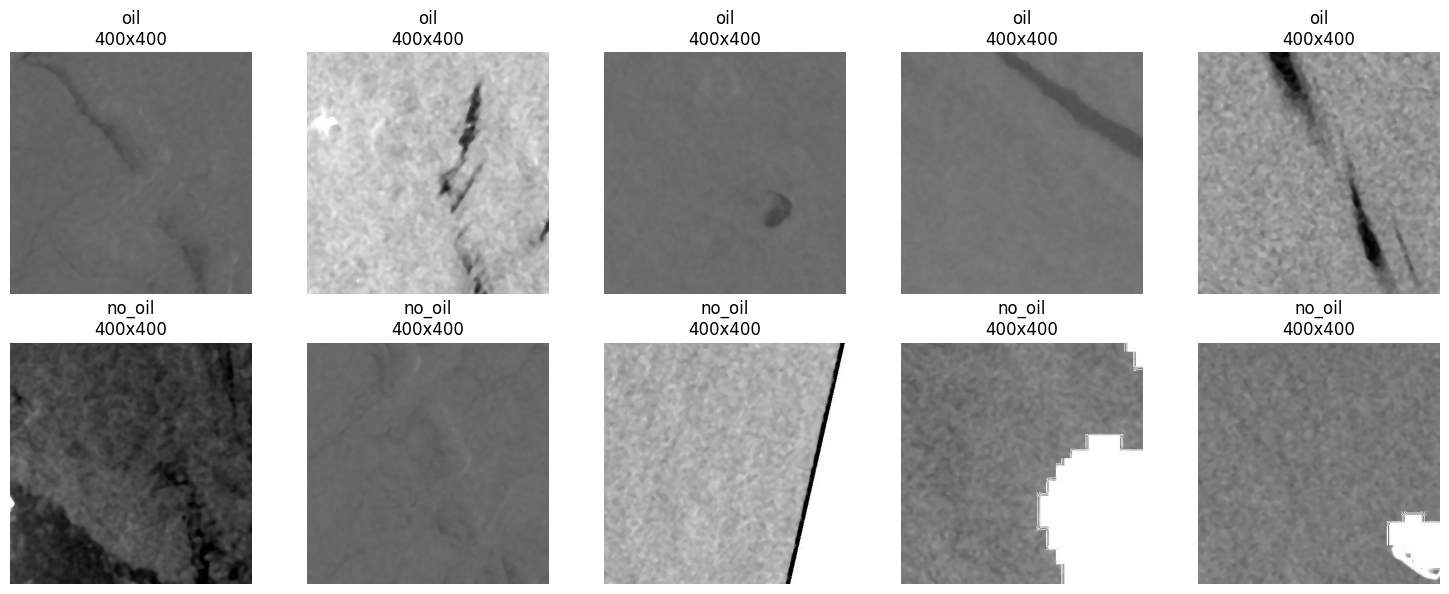

In [ ]:
# Import os (folders) and random (random picking)
import os, random
# Import matplotlib's plotting module (used to draw pictures and graphs)
import matplotlib.pyplot as plt
# Import PIL's Image tool, which opens image files
from PIL import Image

# Fix the random seed so you get the same pictures each time
random.seed(0)
# Create a grid of 2 rows x 5 columns of empty picture slots
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
# Row 0 will show oil images, row 1 will show no_oil images
for row, cls in enumerate(["oil", "no_oil"]):
    # Path of this class's folder
    folder = DATA_DIR + "/" + cls
    # List all file names in that folder
    all_files = os.listdir(folder)
    # Print how many images this class has
    print(cls, ":", len(all_files), "images")
    # Randomly pick up to 5 files to display
    picks = random.sample(all_files, min(5, len(all_files)))
    # Fill the 5 columns of this row
    for col in range(5):
        # Select the picture slot at this row and column
        ax = axes[row, col]
        # Only draw if we actually have an image for this slot
        if col < len(picks):
            # Open the image file
            img = Image.open(os.path.join(folder, picks[col]))
            # Draw it in grey tones (like a radar image)
            ax.imshow(img, cmap="gray")
            # Title = class name + image width x height in pixels
            ax.set_title(cls + "\n" + str(img.size[0]) + "x" + str(img.size[1]))
        # Hide the x/y axis numbers
        ax.axis("off")
# Tidy the spacing between pictures
plt.tight_layout()
# Display the figure
plt.show()

## Cell 6: Split the data, resize to 224×224, normalize, augment, build DataLoaders

In [ ]:
# Import os for folders
import os
# Import torch (the AI framework)
import torch
# Import Dataset (a blueprint for our data) and DataLoader (hands out batches of images)
from torch.utils.data import Dataset, DataLoader
# Import transforms: ready-made image processing steps
from torchvision import transforms
# Import PIL's Image tool to open image files
from PIL import Image
# Import a helper that splits lists into train / validation / test parts
from sklearn.model_selection import train_test_split

# Class names in order: index 0 = no_oil, index 1 = oil
CLASS_NAMES = ["no_oil", "oil"]
# Two empty lists: one for image file paths, one for their numeric labels
paths, labels = [], []
# Go through each class, with its index number (0 or 1)
for idx, cls in enumerate(CLASS_NAMES):
    # Path of this class's folder
    folder = DATA_DIR + "/" + cls
    # Go through every file in the folder (sorted so the order is always the same)
    for f in sorted(os.listdir(folder)):
        # Remember the image's full path
        paths.append(os.path.join(folder, f))
        # Remember its label (0 or 1)
        labels.append(idx)

# First split: 70% for training, 30% held back (stratify keeps the oil / no_oil ratio equal in every part)
train_p, temp_p, train_l, temp_l = train_test_split(paths, labels, test_size=0.30, stratify=labels, random_state=42)
# Second split: cut the held-back 30% in half -> 15% validation, 15% test
val_p, test_p, val_l, test_l = train_test_split(temp_p, temp_l, test_size=0.50, stratify=temp_l, random_state=42)

# The average pixel values (R, G, B) of the ImageNet images the model was originally trained on
IMAGENET_MEAN = [0.485, 0.456, 0.406]
# The spread (standard deviation) of those ImageNet pixel values
IMAGENET_STD = [0.229, 0.224, 0.225]

# Steps applied to TRAINING images (includes random augmentation so the model sees varied versions)
train_tfms = transforms.Compose([
    # Resize every image to 224 x 224 pixels (the size EfficientNet-B0 expects)
    transforms.Resize((224, 224)),
    # Randomly mirror the image left-right half of the time
    transforms.RandomHorizontalFlip(),
    # Randomly mirror the image up-down half of the time
    transforms.RandomVerticalFlip(),
    # Randomly rotate by up to 15 degrees either way
    transforms.RandomRotation(15),
    # Convert the picture into a PyTorch tensor with values between 0 and 1
    transforms.ToTensor(),
    # Shift and scale the values the same way ImageNet images were prepared
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
# Steps for VALIDATION / TEST / new images: same as above but with NO random changes
eval_tfms = transforms.Compose([
    # Resize to 224 x 224
    transforms.Resize((224, 224)),
    # Convert to a tensor
    transforms.ToTensor(),
    # Normalize with the ImageNet numbers
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Define our own Dataset: a small class that knows how to give the model image number i
class SARDataset(Dataset):
    # This runs once when we create the dataset: it stores the lists we give it
    def __init__(self, paths, labels, transform):
        # Save the list of image file paths
        self.paths = paths
        # Save the list of labels
        self.labels = labels
        # Save the transform steps to apply
        self.transform = transform
    # Tell PyTorch how many images the dataset holds
    def __len__(self):
        # The number of image paths
        return len(self.paths)
    # Tell PyTorch how to fetch image number i together with its label
    def __getitem__(self, i):
        # Open the image and convert it to 3 colour channels (SAR chips are 1-channel grey, EfficientNet needs 3)
        img = Image.open(self.paths[i]).convert("RGB")
        # Return the transformed image and its label
        return self.transform(img), self.labels[i]

# Create the three datasets (only training gets the random augmentation)
train_ds = SARDataset(train_p, train_l, train_tfms)
# Validation dataset (no augmentation)
val_ds = SARDataset(val_p, val_l, eval_tfms)
# Test dataset (no augmentation)
test_ds = SARDataset(test_p, test_l, eval_tfms)

# Batch size = how many images the model looks at in one step
BATCH_SIZE = 32
# Training loader: shuffles the images every epoch
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
# Validation loader: no shuffling needed
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
# Test loader: no shuffling needed
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# Print the size of each split and how many no_oil / oil images it has
for name, lab in [("train", train_l), ("val", val_l), ("test", test_l)]:
    # One line per split
    print(name.ljust(5), "->", len(lab), "images | no_oil:", lab.count(0), "| oil:", lab.count(1))
# Grab one batch from the training loader to check that everything works
images, lbls = next(iter(train_loader))
# Print the shape of the image batch: [batch size, channels, height, width]
print("One batch of images:", images.shape)
# Print the shape of the label batch: one label per image
print("One batch of labels:", lbls.shape)

train -> 3876 images | no_oil: 2586 | oil: 1290
val   -> 831 images | no_oil: 554 | oil: 277
test  -> 831 images | no_oil: 555 | oil: 276
One batch of images: torch.Size([32, 3, 224, 224])
One batch of labels: torch.Size([32])


## Cell 7: Load EfficientNet-B0, freeze it, attach a new 2-class head

In [ ]:
# Import torch's neural-network building blocks
import torch.nn as nn
# Import torchvision's collection of ready-made models
from torchvision import models

# Choose the GPU if one exists, otherwise fall back to the (much slower) CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Print which device will do the computing
print("Using device:", device)

# Load EfficientNet-B0 with weights learned on ImageNet (downloads about 20 MB the first time)
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
# Go through every parameter (learnable number) in the model
for param in model.parameters():
    # Freeze it: training will NOT change this number
    param.requires_grad = False

# Replace the final classifier (originally 1000 ImageNet classes) with our own small network
model.classifier = nn.Sequential(
    # Compress the 1280 features EfficientNet produces down to 128
    nn.Linear(1280, 128),
    # ReLU activation: keeps positive values, turns negatives into 0 (lets the network learn non-linear patterns)
    nn.ReLU(),
    # Dropout: randomly switches off 30% of the 128 values during training to reduce overfitting
    nn.Dropout(0.3),
    # Final layer: 128 values -> 2 scores (one for no_oil, one for oil)
    nn.Linear(128, 2),
)
# Move the whole model onto the GPU
model = model.to(device)

# Count ALL numbers in the model
total = sum(p.numel() for p in model.parameters())
# Count only the numbers that training is allowed to change
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
# Print the total parameter count
print("Total parameters    :", format(total, ","))
# Print the trainable parameter count
print("Trainable parameters:", format(trainable, ","))

Using device: cuda
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 109MB/s] 


Total parameters    : 4,171,774
Trainable parameters: 164,226


## Cell 8: Class-weighted loss function + Adam optimizer + scheduler

In [ ]:
# Import torch's optimizer module (Adam lives here)
import torch.optim as optim

# Count how many no_oil (0) and oil (1) images are in the TRAINING set
train_counts = [train_l.count(0), train_l.count(1)]
# Total number of training images
total_train = len(train_l)
# Weight for each class = total / (2 x class count): the rarer class gets the bigger weight
class_weights = torch.tensor(
    # Weight of no_oil and weight of oil
    [total_train / (2 * train_counts[0]), total_train / (2 * train_counts[1])],
    # Use decimal numbers of the type PyTorch expects
    dtype=torch.float32,
# Move the weights to the GPU next to the model
).to(device)
# Print the weights so you can see which class is being boosted
print("Class weights [no_oil, oil]:", class_weights.tolist())

# Loss function: measures how wrong the model is; the weights make mistakes on the rare class cost more
criterion = nn.CrossEntropyLoss(weight=class_weights)
# Adam optimizer: adjusts ONLY the classifier's numbers, starting with a learning rate (step size) of 0.001
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)
# Scheduler: if validation loss does not improve for 2 epochs, halve the learning rate
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)
# Confirm everything is set up
print("Loss, optimizer and scheduler are ready.")

Class weights [no_oil, oil]: [0.7494199275970459, 1.5023255348205566]
Loss, optimizer and scheduler are ready.


## Cell 9: Training loop (15 epochs, saves the best model)

In [ ]:
# Import time (to measure how long training takes)
import time
# Import recall_score (the metric we care about most)
from sklearn.metrics import recall_score

# Number of full passes over the training data
EPOCHS = 15
# File where the best model will be saved
BEST_PATH = "/content/best_model.pth"
# A dictionary of empty lists where we record results after every epoch (used for graphs in Cell 10)
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "val_recall": []}
# Best validation loss seen so far (starts at infinity so the first epoch always counts as an improvement)
best_val_loss = float("inf")
# Note the start time
start = time.time()

# Repeat the whole training + validation cycle once per epoch
for epoch in range(EPOCHS):
    # ---------- TRAINING PART ----------
    # Put the model in training mode (turns Dropout on)
    model.train()
    # Keep the frozen EfficientNet body in evaluation mode so its BatchNorm statistics stay unchanged
    model.features.eval()
    # Running totals for this epoch: loss sum, number correct, number of images seen
    run_loss, correct, seen = 0.0, 0, 0
    # Loop over the training data one batch of 32 images at a time
    for images, targets in train_loader:
        # Move the images to the GPU
        images = images.to(device)
        # Move the correct answers (labels) to the GPU
        targets = targets.to(device)
        # Clear the gradients left over from the previous batch
        optimizer.zero_grad()
        # Forward pass: the model makes predictions (2 scores per image)
        outputs = model(images)
        # Compare predictions with the correct answers to get the loss
        loss = criterion(outputs, targets)
        # Backward pass: work out how each classifier number should change to reduce the loss
        loss.backward()
        # Update the classifier numbers a small step
        optimizer.step()
        # Add this batch's loss to the running total (multiplied by batch size)
        run_loss += loss.item() * images.size(0)
        # Count how many predictions were right (argmax picks the higher of the 2 scores)
        correct += (outputs.argmax(1) == targets).sum().item()
        # Count the images processed
        seen += images.size(0)
    # Average training loss for the epoch
    train_loss = run_loss / seen
    # Training accuracy for the epoch
    train_acc = correct / seen

    # ---------- VALIDATION PART (no learning here, only measuring) ----------
    # Put the model in evaluation mode (turns Dropout off)
    model.eval()
    # Running totals for validation
    v_loss, v_correct, v_seen = 0.0, 0, 0
    # Lists to collect every prediction and true label (needed for recall)
    all_preds, all_true = [], []
    # Tell PyTorch not to track gradients (saves memory and time)
    with torch.no_grad():
        # Loop over the validation data in batches
        for images, targets in val_loader:
            # Move images to the GPU
            images = images.to(device)
            # Move labels to the GPU
            targets = targets.to(device)
            # Get the model's predictions
            outputs = model(images)
            # Compute the loss for this batch
            loss = criterion(outputs, targets)
            # Add to the running loss total
            v_loss += loss.item() * images.size(0)
            # Pick the predicted class (0 or 1) for every image
            preds = outputs.argmax(1)
            # Count correct predictions
            v_correct += (preds == targets).sum().item()
            # Count images
            v_seen += images.size(0)
            # Save predictions (moved back to the CPU as plain Python lists)
            all_preds.extend(preds.cpu().tolist())
            # Save the true labels the same way
            all_true.extend(targets.cpu().tolist())
    # Average validation loss
    val_loss = v_loss / v_seen
    # Validation accuracy
    val_acc = v_correct / v_seen
    # Recall on the oil class: of all REAL oil images, what fraction did the model catch?
    val_recall = recall_score(all_true, all_preds, pos_label=1, zero_division=0)

    # Tell the scheduler the validation loss so it can lower the learning rate if progress stalls
    scheduler.step(val_loss)
    # Save this epoch's numbers for the graphs later
    history["train_loss"].append(train_loss)
    # Save validation loss
    history["val_loss"].append(val_loss)
    # Save training accuracy
    history["train_acc"].append(train_acc)
    # Save validation accuracy
    history["val_acc"].append(val_acc)
    # Save validation oil-recall
    history["val_recall"].append(val_recall)

    # If this is the best validation loss so far, save the model to disk
    if val_loss < best_val_loss:
        # Remember the new best value
        best_val_loss = val_loss
        # Save the model's numbers to the file
        torch.save(model.state_dict(), BEST_PATH)
        # Put a star in the printout to show a new best model
        star = "  <- saved best"
    # Otherwise no star
    else:
        # Empty text
        star = ""
    # Print one summary line for this epoch
    print(f"Epoch {epoch+1:02d}/{EPOCHS} | train loss {train_loss:.4f} acc {train_acc:.3f} | "
          f"val loss {val_loss:.4f} acc {val_acc:.3f} oil-recall {val_recall:.3f} | "
          f"lr {optimizer.param_groups[0]['lr']:.5f}{star}")

# Print the total training time in minutes
print(f"\nDone! Training took {(time.time() - start) / 60:.1f} minutes. Best val loss: {best_val_loss:.4f}")

Epoch 01/15 | train loss 0.3461 acc 0.849 | val loss 0.2147 acc 0.912 oil-recall 0.968 | lr 0.00100  <- saved best
Epoch 02/15 | train loss 0.2112 acc 0.916 | val loss 0.1929 acc 0.911 oil-recall 0.971 | lr 0.00100  <- saved best
Epoch 03/15 | train loss 0.1866 acc 0.927 | val loss 0.1677 acc 0.929 oil-recall 0.942 | lr 0.00100  <- saved best
Epoch 04/15 | train loss 0.1731 acc 0.935 | val loss 0.1580 acc 0.936 oil-recall 0.968 | lr 0.00100  <- saved best
Epoch 05/15 | train loss 0.1634 acc 0.937 | val loss 0.1492 acc 0.949 oil-recall 0.910 | lr 0.00100  <- saved best
Epoch 06/15 | train loss 0.1500 acc 0.940 | val loss 0.1387 acc 0.955 oil-recall 0.946 | lr 0.00100  <- saved best
Epoch 07/15 | train loss 0.1440 acc 0.947 | val loss 0.1738 acc 0.923 oil-recall 0.986 | lr 0.00100
Epoch 08/15 | train loss 0.1468 acc 0.943 | val loss 0.1203 acc 0.954 oil-recall 0.953 | lr 0.00100  <- saved best
Epoch 09/15 | train loss 0.1307 acc 0.950 | val loss 0.1291 acc 0.959 oil-recall 0.964 | lr 0.0

## Cell 10: Learning curves

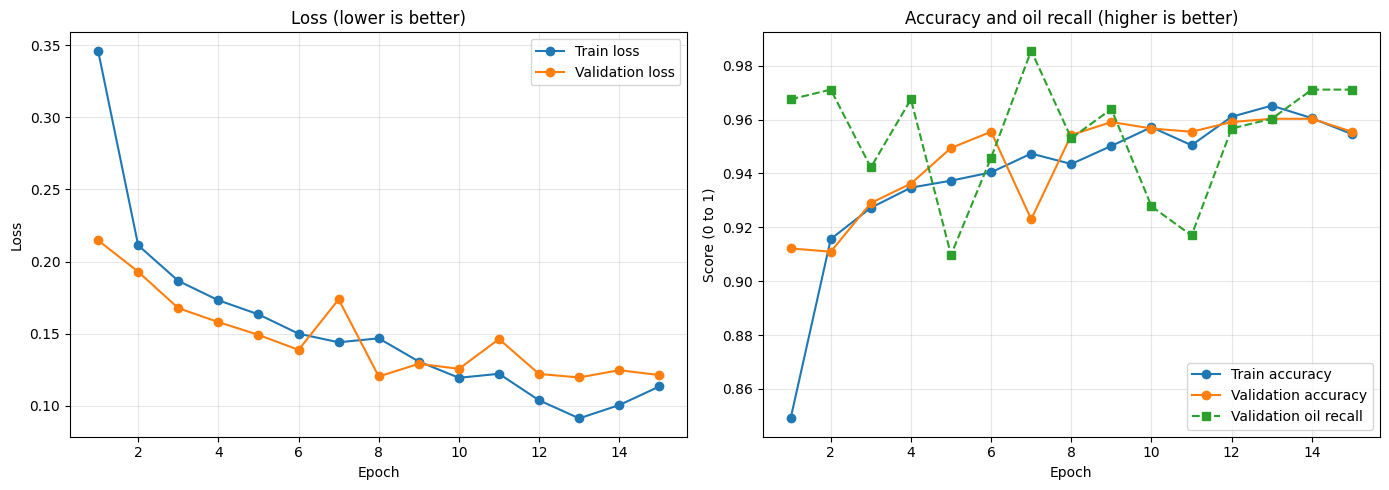

In [ ]:
# Import matplotlib for drawing graphs
import matplotlib.pyplot as plt
# The x-axis values: epoch numbers 1, 2, 3, ...
epochs_range = range(1, len(history["train_loss"]) + 1)
# Create 2 graphs side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
# Left graph: training loss line
ax1.plot(epochs_range, history["train_loss"], marker="o", label="Train loss")
# Left graph: validation loss line
ax1.plot(epochs_range, history["val_loss"], marker="o", label="Validation loss")
# Left graph title
ax1.set_title("Loss (lower is better)")
# Left graph x-axis label
ax1.set_xlabel("Epoch")
# Left graph y-axis label
ax1.set_ylabel("Loss")
# Show the legend (which line is which)
ax1.legend()
# Add light grid lines
ax1.grid(alpha=0.3)
# Right graph: training accuracy line
ax2.plot(epochs_range, history["train_acc"], marker="o", label="Train accuracy")
# Right graph: validation accuracy line
ax2.plot(epochs_range, history["val_acc"], marker="o", label="Validation accuracy")
# Right graph: validation oil-recall line (our most important metric)
ax2.plot(epochs_range, history["val_recall"], marker="s", linestyle="--", label="Validation oil recall")
# Right graph title
ax2.set_title("Accuracy and oil recall (higher is better)")
# Right graph x-axis label
ax2.set_xlabel("Epoch")
# Right graph y-axis label
ax2.set_ylabel("Score (0 to 1)")
# Show the legend
ax2.legend()
# Add light grid lines
ax2.grid(alpha=0.3)
# Tidy the layout
plt.tight_layout()
# Display the graphs
plt.show()

## Cell 11: Final exam on the TEST set: classification report + confusion matrix

              precision    recall  f1-score   support

      no_oil      0.970     0.939     0.954       555
         oil      0.884     0.942     0.912       276

    accuracy                          0.940       831
   macro avg      0.927     0.940     0.933       831
weighted avg      0.942     0.940     0.940       831



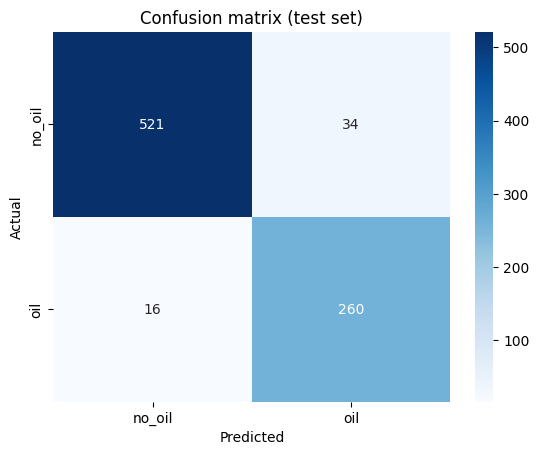

OIL RECALL: 0.942  (260 of 276 real oil images caught, 16 missed)


In [ ]:
# Import metric tools from scikit-learn
from sklearn.metrics import classification_report, confusion_matrix
# Import seaborn (makes nice heatmaps)
import seaborn as sns
# Import matplotlib for drawing
import matplotlib.pyplot as plt

# Load the BEST saved model numbers back into the model
model.load_state_dict(torch.load(BEST_PATH, map_location=device))
# Switch to evaluation mode
model.eval()
# Lists to collect predictions and true labels
all_preds, all_true = [], []
# Do not track gradients (we are only measuring)
with torch.no_grad():
    # Loop over the TEST data (images the model has never trained or tuned on)
    for images, targets in test_loader:
        # Move images to the GPU
        images = images.to(device)
        # Get predictions and pick the class with the higher score
        preds = model(images).argmax(1)
        # Save predictions as plain Python numbers
        all_preds.extend(preds.cpu().tolist())
        # Save the true labels
        all_true.extend(targets.tolist())

# Print precision, recall and F1 for each class
print(classification_report(all_true, all_preds, target_names=CLASS_NAMES, digits=3))
# Build the confusion matrix: rows = true class, columns = predicted class
cm = confusion_matrix(all_true, all_preds)
# Draw the matrix as a coloured heatmap with the numbers written inside
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
# Label the x-axis
plt.xlabel("Predicted")
# Label the y-axis
plt.ylabel("Actual")
# Give the graph a title
plt.title("Confusion matrix (test set)")
# Display the graph
plt.show()
# Oil recall = real oil images caught / all real oil images (row 1 of the matrix)
print(f"OIL RECALL: {cm[1, 1] / cm[1].sum():.3f}  ({cm[1, 1]} of {cm[1].sum()} real oil images caught, {cm[1, 0]} missed)")

## Cell 12: Predict on new SAR images you upload

In [ ]:
# Import Colab's upload helper
from google.colab import files
# Import softmax (turns 2 raw scores into 2 probabilities that add up to 1)
import torch.nn.functional as F
# Import matplotlib for showing the image
import matplotlib.pyplot as plt
# Import PIL's Image tool
from PIL import Image

# Show an upload button so you can pick one or more SAR images from your computer
uploaded = files.upload()
# Switch the model to evaluation mode
model.eval()
# Go through each uploaded file name
for fname in uploaded.keys():
    # Open the image and convert it to 3 channels
    img = Image.open(fname).convert("RGB")
    # Apply the same preparation as the test images, add a batch dimension, move to the GPU
    x = eval_tfms(img).unsqueeze(0).to(device)
    # Do not track gradients
    with torch.no_grad():
        # Get the model's scores and turn them into probabilities for this single image
        probs = F.softmax(model(x), dim=1)[0]
    # Find which class has the higher probability (0 or 1)
    pred = int(probs.argmax())
    # Look up the class name and choose a display label
    label = "OIL" if CLASS_NAMES[pred] == "oil" else "NO OIL"
    # Create a small figure
    plt.figure(figsize=(4, 4))
    # Show the image
    plt.imshow(img)
    # Hide axis numbers
    plt.axis("off")
    # Title = prediction and confidence
    plt.title(label + f"  ({probs[pred].item() * 100:.1f}% confident)")
    # Display it
    plt.show()
    # Also print both probabilities as text
    print(fname, "-> no_oil:", f"{probs[0].item():.3f}", "| oil:", f"{probs[1].item():.3f}")

KeyboardInterrupt: 

## Cell 13: Save the trained model and download it to your computer

In [ ]:
# Import Colab's download helper
from google.colab import files
# Name of the file to create
SAVE_PATH = "/content/oil_spill_efficientnet_b0.pth"
# Save the model's learned numbers together with the class names
torch.save({"model_state_dict": model.state_dict(), "class_names": CLASS_NAMES}, SAVE_PATH)
# Print confirmation
print("Saved to", SAVE_PATH)
# Start the download to your computer (your browser may ask permission)
files.download(SAVE_PATH)

Saved to /content/oil_spill_efficientnet_b0.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Import Colab's Google Drive helper
from google.colab import drive
# Connect your Google Drive (a permission window will pop up: click Connect / Allow)
drive.mount("/content/drive")



In [ ]:
# Import Colab's Google Drive helper
from google.colab import drive
# Connect your Google Drive (a permission window will pop up: click Connect / Allow)
drive.mount("/content/drive")


Mounted at /content/drive


In [ ]:
# Import zipfile, Python's built-in tool for looking inside zip files
import zipfile
# Import os, Python's built-in tool for working with folders
import os

# Your Kochi scene's zip file path
ZIP_PATH = "/content/drive/MyDrive/Downloads/S1A_IW_GRDH_1SDV_20250614T004918_20250614T004941_059635_07678A_F7B9.zip"

# Open the zip file so we can look inside it
with zipfile.ZipFile(ZIP_PATH, "r") as z:
    # Get a list of every file's name inside the zip
    names = z.namelist()
    # Find the one file that ends with "manifest.safe" - this holds the metadata
    manifest_name = [n for n in names if n.endswith("manifest.safe")][0]
    # Find ALL the actual satellite picture files (there will likely be 2: one VV, one VH)
    all_tiffs = [n for n in names if n.endswith(".tiff") and "measurement" in n]
    # Print every image file found, so we can see their names and pick the right one
    print("All image files found in this scene:")
    for t in all_tiffs:
        print(" -", t)
    # Filter to keep only the one with "vv" in its filename (case-insensitive)
    vv_tiffs = [t for t in all_tiffs if "vv" in t.lower()]
    # Make sure we actually found a VV file before continuing
    if not vv_tiffs:
        print("WARNING: no VV file found! Check the names printed above.")
    else:
        # Take the VV file specifically
        tiff_name = vv_tiffs[0]
        # Make a new empty folder to put our extracted files into
        os.makedirs("/content/scene", exist_ok=True)
        # Pull just the metadata file out of the zip
        z.extract(manifest_name, "/content/scene")
        # Pull just the VV picture file out of the zip
        z.extract(tiff_name, "/content/scene")
        # Remember the full paths
        MANIFEST_PATH = "/content/scene/" + manifest_name
        TIFF_PATH = "/content/scene/" + tiff_name
        # Confirm which file we picked
        print("\nUsing VV image:", TIFF_PATH)
        print("Using metadata:", MANIFEST_PATH)

All image files found in this scene:
 - S1A_IW_GRDH_1SDV_20250614T004918_20250614T004941_059635_07678A_F7B9.SAFE/measurement/s1a-iw-grd-vh-20250614t004918-20250614t004941-059635-07678a-002.tiff
 - S1A_IW_GRDH_1SDV_20250614T004918_20250614T004941_059635_07678A_F7B9.SAFE/measurement/s1a-iw-grd-vv-20250614t004918-20250614t004941-059635-07678a-001.tiff

Using VV image: /content/scene/S1A_IW_GRDH_1SDV_20250614T004918_20250614T004941_059635_07678A_F7B9.SAFE/measurement/s1a-iw-grd-vv-20250614t004918-20250614t004941-059635-07678a-001.tiff
Using metadata: /content/scene/S1A_IW_GRDH_1SDV_20250614T004918_20250614T004941_059635_07678A_F7B9.SAFE/manifest.safe


In [ ]:
# Import re, Python's built-in tool for finding patterns of text
import re

# Open the metadata file and read all its text
with open(MANIFEST_PATH, "r") as f:
    manifest_text = f.read()

# Find the acquisition start time - this tells us exactly when the satellite took the picture
start_time = re.search(r"<safe:startTime>(.*?)</safe:startTime>", manifest_text).group(1)

# Find the block of text listing the scene's 4 corner coordinates
coords_match = re.search(r"<gml:coordinates>(.*?)</gml:coordinates>", manifest_text).group(1)

# Split that text into 4 separate (latitude, longitude) pairs
corners = [tuple(map(float, pair.split(","))) for pair in coords_match.strip().split(" ")]

# Print the acquisition time
print("Acquisition time (UTC):", start_time)
# Print all 4 corners so we can check they make sense
print("Scene corners (lat, lon):")
for c in corners:
    print("  ", c)

Acquisition time (UTC): 2025-06-14T00:49:18.961701
Scene corners (lat, lon):
   (9.302558, 75.855225)
   (9.757897, 73.574509)
   (11.102741, 73.840843)
   (10.650948, 76.131874)


Full image size: 25543 x 14931 pixels


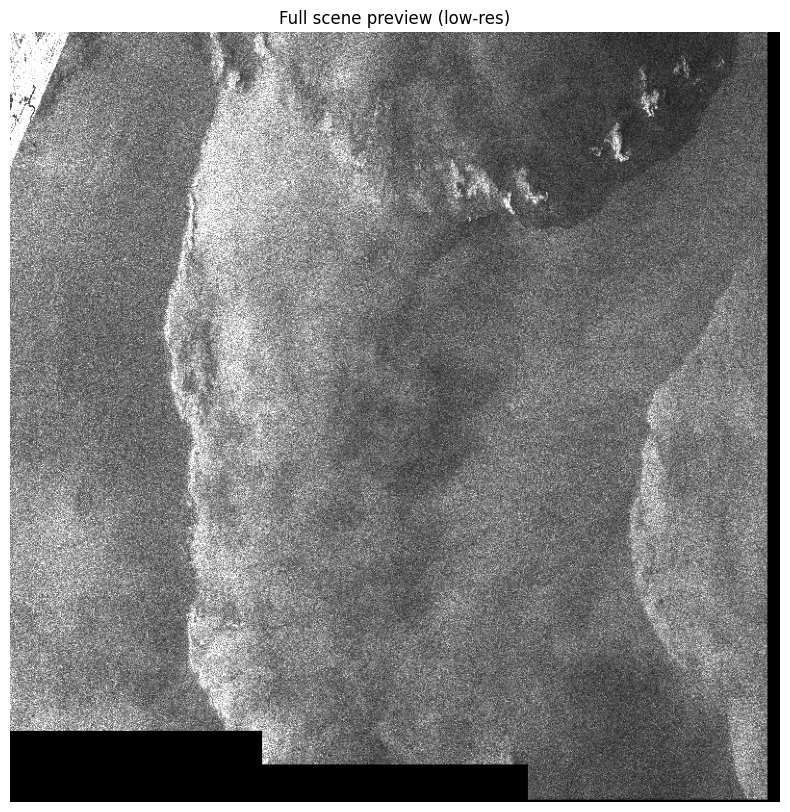

In [ ]:
# Import rasterio to open the satellite image
import rasterio
# Import numpy for number handling
import numpy as np
# Import matplotlib to draw the picture
import matplotlib.pyplot as plt

# Open the big radar image
with rasterio.open(TIFF_PATH) as src:
    # Print the full image dimensions
    print("Full image size:", src.width, "x", src.height, "pixels")
    # Read the WHOLE image but shrunk down to a manageable small size for preview only
    # (out_shape controls how small - this keeps it fast and light on memory)
    preview = src.read(1, out_shape=(800, 800))

# Clip extreme values and stretch contrast so we can actually see something
lo, hi = np.percentile(preview, (2, 98))
stretched = np.clip((preview - lo) / (hi - lo + 1e-6) * 255, 0, 255).astype(np.uint8)

# Draw it
plt.figure(figsize=(10, 10))
plt.imshow(stretched, cmap="gray")
plt.title("Full scene preview (low-res)")
plt.axis("off")
plt.show()


In [ ]:
# Import numpy for the math below
import numpy as np

# The real, publicly reported location where MSC Elsa 3 sank
# We use this ONLY to find where to look in the image - not as an input to the AI model
TARGET_LAT = 9.3125
TARGET_LON = 76.136

# Try many possible positions within the image to find which one is closest to our target
fracs = np.linspace(0, 1, 300)
best_dist = None
best_frac = None
for fr in fracs:
    for fc in fracs:
        # Estimate the lat/lon at this position, same math as before
        lat = (corners[0][0]*(1-fr) + corners[3][0]*fr) * (1-fc) + \
              (corners[1][0]*(1-fr) + corners[2][0]*fr) * fc
        lon = (corners[0][1]*(1-fr) + corners[3][1]*fr) * (1-fc) + \
              (corners[1][1]*(1-fr) + corners[2][1]*fr) * fc
        # How far is this from our target?
        dist = (lat - TARGET_LAT)**2 + (lon - TARGET_LON)**2
        # Keep track of the closest match found so far
        if best_dist is None or dist < best_dist:
            best_dist = dist
            best_frac = (fr, fc)

# Print the result
print("Best matching position (fraction down, fraction across):", best_frac)
print("How close this match is (smaller = better):", round(best_dist, 6))
# Warn if the best match is right at an edge - meaning the


Best matching position (fraction down, fraction across): (np.float64(0.046822742474916385), np.float64(0.0))
How close this match is (smaller = better): 0.074558


In [ ]:
# Import os to check if a file exists
import os
# The path we're guessing
guess_path = "//content/drive/MyDrive/Google AI Studio/Downloads/S1A_IW_GRDH_1SDV_20250528T004137_20250528T004157_059387_075F14_1A66.zip"
# Check if that exact file exists
print("File found?", os.path.exists(guess_path))

File found? True


In [ ]:
# Import zipfile, Python's built-in tool for looking inside zip files
import zipfile
# Import os, Python's built-in tool for working with folders
import os

# Your new May 28 Kochi scene's zip file path
ZIP_PATH = "/content/drive/MyDrive/Google AI Studio/Downloads/S1A_IW_GRDH_1SDV_20250528T004137_20250528T004157_059387_075F14_1A66.zip"

# Open the zip file so we can look inside it
with zipfile.ZipFile(ZIP_PATH, "r") as z:
    # Get a list of every file's name inside the zip
    names = z.namelist()
    # Find the one file that ends with "manifest.safe" - this holds the metadata
    manifest_name = [n for n in names if n.endswith("manifest.safe")][0]
    # Find ALL the actual satellite picture files (there will likely be 2: one VV, one VH)
    all_tiffs = [n for n in names if n.endswith(".tiff") and "measurement" in n]
    # Print every image file found, so we can see their names and pick the right one
    print("All image files found in this scene:")
    for t in all_tiffs:
        print(" -", t)
    # Filter to keep only the one with "vv" in its filename (case-insensitive)
    vv_tiffs = [t for t in all_tiffs if "vv" in t.lower()]
    # Make sure we actually found a VV file before continuing
    if not vv_tiffs:
        print("WARNING: no VV file found! Check the names printed above.")
    else:
        # Take the VV file specifically
        tiff_name = vv_tiffs[0]
        # Make a new empty folder to put our extracted files into
        os.makedirs("/content/scene", exist_ok=True)
        # Pull just the metadata file out of the zip
        z.extract(manifest_name, "/content/scene")
        # Pull just the VV picture file out of the zip
        z.extract(tiff_name, "/content/scene")
        # Remember the full paths
        MANIFEST_PATH = "/content/scene/" + manifest_name
        TIFF_PATH = "/content/scene/" + tiff_name
        # Confirm which file we picked
        print("\nUsing VV image:", TIFF_PATH)
        print("Using metadata:", MANIFEST_PATH)

All image files found in this scene:
 - S1A_IW_GRDH_1SDV_20250528T004137_20250528T004157_059387_075F14_1A66.SAFE/measurement/s1a-iw-grd-vh-20250528t004137-20250528t004157-059387-075f14-002.tiff
 - S1A_IW_GRDH_1SDV_20250528T004137_20250528T004157_059387_075F14_1A66.SAFE/measurement/s1a-iw-grd-vv-20250528t004137-20250528t004157-059387-075f14-001.tiff

Using VV image: /content/scene/S1A_IW_GRDH_1SDV_20250528T004137_20250528T004157_059387_075F14_1A66.SAFE/measurement/s1a-iw-grd-vv-20250528t004137-20250528t004157-059387-075f14-001.tiff
Using metadata: /content/scene/S1A_IW_GRDH_1SDV_20250528T004137_20250528T004157_059387_075F14_1A66.SAFE/manifest.safe


In [ ]:
# Import re, Python's built-in tool for finding patterns of text
import re

# Open the metadata file and read all its text
with open(MANIFEST_PATH, "r") as f:
    manifest_text = f.read()

# Find the acquisition start time - this tells us exactly when the satellite took the picture
start_time = re.search(r"<safe:startTime>(.*?)</safe:startTime>", manifest_text).group(1)

# Find the block of text listing the scene's 4 corner coordinates
coords_match = re.search(r"<gml:coordinates>(.*?)</gml:coordinates>", manifest_text).group(1)

# Split that text into 4 separate (latitude, longitude) pairs
corners = [tuple(map(float, pair.split(","))) for pair in coords_match.strip().split(" ")]

# Print the acquisition time
print("Acquisition time (UTC):", start_time)
# Print all 4 corners so we can check they make sense
print("Scene corners (lat, lon):")
for c in corners:
    print("  ", c)

Acquisition time (UTC): 2025-05-28T00:41:37.669955
Scene corners (lat, lon):
   (7.574316, 77.557083)
   (8.034481, 75.286789)
   (9.202539, 75.517105)
   (8.745565, 77.794769)


In [ ]:
# Import numpy for the math below
import numpy as np

# The real, publicly reported location where MSC Elsa 3 sank
TARGET_LAT = 9.3125
TARGET_LON = 76.136

# Try many possible positions within the image to find which one is closest to our target
fracs = np.linspace(0, 1, 300)
best_dist = None
best_frac = None
for fr in fracs:
    for fc in fracs:
        # Estimate the lat/lon at this position, same math as before
        lat = (corners[0][0]*(1-fr) + corners[3][0]*fr) * (1-fc) + \
              (corners[1][0]*(1-fr) + corners[2][0]*fr) * fc
        lon = (corners[0][1]*(1-fr) + corners[3][1]*fr) * (1-fc) + \
              (corners[1][1]*(1-fr) + corners[2][1]*fr) * fc
        # How far is this from our target?
        dist = (lat - TARGET_LAT)**2 + (lon - TARGET_LON)**2
        # Keep track of the closest match found so far
        if best_dist is None or dist < best_dist:
            best_dist = dist
            best_frac = (fr, fc)

# Print the result
print("Best matching position (fraction down, fraction across):", best_frac)
print("How close this match is (smaller = better):", round(best_dist, 6))
# Warn if the best match is right at an edge - meaning the real point might be outside this image
if best_frac[0] in (0.0, fracs[-1]) or best_frac[1] in (0.0, fracs[-1]):
    print("NOTE: best match is at the edge of the image - the real location may be just outside this scene's coverage.")

Best matching position (fraction down, fraction across): (np.float64(1.0), np.float64(0.7491638795986622))
How close this match is (smaller = better): 0.052702
NOTE: best match is at the edge of the image - the real location may be just outside this scene's coverage.


In [ ]:
# Import rasterio to open the satellite image
import rasterio
# Import numpy for number crunching
import numpy as np
# Import PIL to save tile images
from PIL import Image
# Import softmax to turn model scores into probabilities
import torch.nn.functional as F
# Import pandas to build the final results table
import pandas as pd
# Import os for folders
import os

# Folder to save the tile images
CHIP_DIR = "/content/scene_chips"
os.makedirs(CHIP_DIR, exist_ok=True)
# Each tile is 400x400 pixels, matching your training data
CHIP_SIZE = 400

# Open the big radar image
with rasterio.open(TIFF_PATH) as src:
    width, height = src.width, src.height
    print("Full scene size:", width, "x", height, "pixels")

    chip_records = []
    chip_id = 0

    # Step through the image in a grid, one tile at a time
    for row in range(0, height - CHIP_SIZE, CHIP_SIZE):
        for col in range(0, width - CHIP_SIZE, CHIP_SIZE):
            window = rasterio.windows.Window(col, row, CHIP_SIZE, CHIP_SIZE)
            tile = src.read(1, window=window)

            # Skip tiles that are mostly empty (edges/padding)
            if np.count_nonzero(tile) < (CHIP_SIZE * CHIP_SIZE * 0.5):
                continue

            # Contrast-stretch so it looks like training data
            lo, hi = np.percentile(tile, (2, 98))
            stretched = np.clip((tile - lo) / (hi - lo + 1e-6) * 255, 0, 255).astype(np.uint8)

            fname = f"chip_{chip_id:04d}.png"
            Image.fromarray(stretched).save(os.path.join(CHIP_DIR, fname))

            # Calculate this tile's real-world position
            frac_row, frac_col = (row + CHIP_SIZE/2) / height, (col + CHIP_SIZE/2) / width
            lat = (corners[0][0]*(1-frac_row) + corners[3][0]*frac_row) * (1-frac_col) + \
                  (corners[1][0]*(1-frac_row) + corners[2][0]*frac_row) * frac_col
            lon = (corners[0][1]*(1-frac_row) + corners[3][1]*frac_row) * (1-frac_col) + \
                  (corners[1][1]*(1-frac_row) + corners[2][1]*frac_row) * frac_col

            chip_records.append({"chip_id": fname, "lat": round(lat, 5), "lon": round(lon, 5)})
            chip_id += 1

print(f"Created {chip_id} tiles")

# Run your trained model on every tile
model.eval()
detections = []
for rec in chip_records:
    img = Image.open(os.path.join(CHIP_DIR, rec["chip_id"])).convert("RGB")
    x = eval_tfms(img).unsqueeze(0).to(device)
    with torch.no_grad():
        p_oil = F.softmax(model(x), dim=1)[0, 1].item()
    detections.append({
        **rec,
        "timestamp_utc": start_time,
        "oil_probability": round(p_oil, 4),
        "predicted_label": "oil" if p_oil >= 0.5 else "no_oil"
    })

df = pd.DataFrame(detections)
df.to_csv("/content/kochi_detections.csv", index=False)
print(f"{(df['predicted_label']=='oil').sum()} of {len(df)} tiles flagged as oil")
print(df.head(10))

Full scene size: 25553 x 12965 pixels
Created 1931 tiles


NameError: name 'eval_tfms' is not defined

In [ ]:
# Import torch and the model-building pieces
import torch
import torch.nn as nn
from torchvision import models

# Pick GPU if available, otherwise CPU (this will just say CPU for now, that's fine)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Rebuild the exact same architecture as training
model = models.efficientnet_b0(weights=None)
model.classifier = nn.Sequential(
    nn.Linear(1280, 128),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(128, 2),
)

# CHANGE THIS to wherever your saved .pth file is (Drive path)
MODEL_PATH = "/content/drive/MyDrive/oil_spill_efficientnet_b0.pth"
checkpoint = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(device)
model.eval()
print("Model loaded successfully")


Using device: cpu
Model loaded successfully


In [ ]:
# Check if we still have the June 14 scene's info loaded
try:
    print("TIFF_PATH:", TIFF_PATH)
    print("Corners:", corners)
    print("Start time:", start_time)
except NameError:
    print("Session was reset - we need to re-extract the June 14 scene first")

Session was reset - we need to re-extract the June 14 scene first


In [ ]:
# ===== RECONNECT DRIVE =====
from google.colab import drive
drive.mount("/content/drive")

# ===== RELOAD YOUR TRAINED MODEL =====
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = models.efficientnet_b0(weights=None)
model.classifier = nn.Sequential(
    nn.Linear(1280, 128),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(128, 2),
)
# CHANGE THIS if your model file is somewhere else
MODEL_PATH = "/content/drive/MyDrive/oil_spill_efficientnet_b0.pth"
checkpoint = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(device)
model.eval()
print("Model loaded")

# ===== RECREATE THE IMAGE PREPARATION STEPS =====
from torchvision import transforms
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
eval_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
print("eval_tfms ready")

# ===== RE-EXTRACT THE MAY 28 SCENE (1A66) =====
import zipfile, os

ZIP_PATH = "/content/drive/MyDrive/Google AI Studio/Downloads/S1A_IW_GRDH_1SDV_20250528T004137_20250528T004157_059387_075F14_1A66.zip"
with zipfile.ZipFile(ZIP_PATH, "r") as z:
    names = z.namelist()
    manifest_name = [n for n in names if n.endswith("manifest.safe")][0]
    all_tiffs = [n for n in names if n.endswith(".tiff") and "measurement" in n]
    vv_tiffs = [t for t in all_tiffs if "vv" in t.lower()]
    tiff_name = vv_tiffs[0]
    os.makedirs("/content/scene", exist_ok=True)
    z.extract(manifest_name, "/content/scene")
    z.extract(tiff_name, "/content/scene")
    MANIFEST_PATH = "/content/scene/" + manifest_name
    TIFF_PATH = "/content/scene/" + tiff_name
print("Extracted image:", TIFF_PATH)

# ===== RE-READ THE METADATA =====
import re
with open(MANIFEST_PATH, "r") as f:
    manifest_text = f.read()
start_time = re.search(r"<safe:startTime>(.*?)</safe:startTime>", manifest_text).group(1)
coords_match = re.search(r"<gml:coordinates>(.*?)</gml:coordinates>", manifest_text).group(1)
corners = [tuple(map(float, pair.split(","))) for pair in coords_match.strip().split(" ")]
print("Acquisition time:", start_time)
print("Corners:", corners)

print("\n=== EVERYTHING RESTORED - READY FOR TILING ===")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cpu
Model loaded
eval_tfms ready
Extracted image: /content/scene/S1A_IW_GRDH_1SDV_20250528T004137_20250528T004157_059387_075F14_1A66.SAFE/measurement/s1a-iw-grd-vv-20250528t004137-20250528t004157-059387-075f14-001.tiff
Acquisition time: 2025-05-28T00:41:37.669955
Corners: [(7.574316, 77.557083), (8.034481, 75.286789), (9.202539, 75.517105), (8.745565, 77.794769)]

=== EVERYTHING RESTORED - READY FOR TILING ===


In [ ]:
# Import rasterio to open the satellite image
import rasterio
# Import numpy for number crunching
import numpy as np
# Import PIL to save tile images
from PIL import Image
# Import softmax to turn model scores into probabilities
import torch.nn.functional as F
# Import pandas to build the final results table
import pandas as pd
# Import os for folders
import os

# Folder to save the tile images
CHIP_DIR = "/content/scene_chips"
os.makedirs(CHIP_DIR, exist_ok=True)
# Each tile is 400x400 pixels, matching your training data
CHIP_SIZE = 400

# Open the big radar image
with rasterio.open(TIFF_PATH) as src:
    width, height = src.width, src.height
    print("Full scene size:", width, "x", height, "pixels")

    chip_records = []
    chip_id = 0

    # Step through the image in a grid, one tile at a time
    for row in range(0, height - CHIP_SIZE, CHIP_SIZE):
        for col in range(0, width - CHIP_SIZE, CHIP_SIZE):
            window = rasterio.windows.Window(col, row, CHIP_SIZE, CHIP_SIZE)
            tile = src.read(1, window=window)

            # Skip tiles that are mostly empty (edges/padding)
            if np.count_nonzero(tile) < (CHIP_SIZE * CHIP_SIZE * 0.5):
                continue

            # Contrast-stretch so it looks like training data
            lo, hi = np.percentile(tile, (2, 98))
            stretched = np.clip((tile - lo) / (hi - lo + 1e-6) * 255, 0, 255).astype(np.uint8)

            fname = f"chip_{chip_id:04d}.png"
            Image.fromarray(stretched).save(os.path.join(CHIP_DIR, fname))

            # Calculate this tile's real-world position
            frac_row, frac_col = (row + CHIP_SIZE/2) / height, (col + CHIP_SIZE/2) / width
            lat = (corners[0][0]*(1-frac_row) + corners[3][0]*frac_row) * (1-frac_col) + \
                  (corners[1][0]*(1-frac_row) + corners[2][0]*frac_row) * frac_col
            lon = (corners[0][1]*(1-frac_row) + corners[3][1]*frac_row) * (1-frac_col) + \
                  (corners[1][1]*(1-frac_row) + corners[2][1]*frac_row) * frac_col

            chip_records.append({"chip_id": fname, "lat": round(lat, 5), "lon": round(lon, 5)})
            chip_id += 1

print(f"Created {chip_id} tiles")

# Run your trained model on every tile
model.eval()
detections = []
for rec in chip_records:
    img = Image.open(os.path.join(CHIP_DIR, rec["chip_id"])).convert("RGB")
    x = eval_tfms(img).unsqueeze(0).to(device)
    with torch.no_grad():
        p_oil = F.softmax(model(x), dim=1)[0, 1].item()
    detections.append({
        **rec,
        "timestamp_utc": start_time,
        "oil_probability": round(p_oil, 4),
        "predicted_label": "oil" if p_oil >= 0.5 else "no_oil"
    })

df = pd.DataFrame(detections)
df.to_csv("/content/kochi_detections.csv", index=False)
print(f"{(df['predicted_label']=='oil').sum()} of {len(df)} tiles flagged as oil")
print(df.head(10))

Full scene size: 25553 x 12965 pixels
Created 1931 tiles
124 of 1931 tiles flagged as oil
         chip_id      lat       lon               timestamp_utc  \
0  chip_0000.png  7.59599  77.54298  2025-05-28T00:41:37.669955   
1  chip_0001.png  7.60319  77.50744  2025-05-28T00:41:37.669955   
2  chip_0002.png  7.61039  77.47190  2025-05-28T00:41:37.669955   
3  chip_0003.png  7.61759  77.43636  2025-05-28T00:41:37.669955   
4  chip_0004.png  7.62480  77.40082  2025-05-28T00:41:37.669955   
5  chip_0005.png  7.63200  77.36528  2025-05-28T00:41:37.669955   
6  chip_0006.png  7.63920  77.32974  2025-05-28T00:41:37.669955   
7  chip_0007.png  7.64640  77.29420  2025-05-28T00:41:37.669955   
8  chip_0008.png  7.65361  77.25866  2025-05-28T00:41:37.669955   
9  chip_0009.png  7.66081  77.22312  2025-05-28T00:41:37.669955   

   oil_probability predicted_label  
0           0.1972          no_oil  
1           0.0514          no_oil  
2           0.9978             oil  
3           0.9924      

In [ ]:
# Import numpy for the distance math
import numpy as np

# The real, publicly reported location where MSC Elsa 3 sank
TARGET_LAT = 9.3125
TARGET_LON = 76.136

# Only look at tiles the model flagged as oil
oil_only = df[df["predicted_label"] == "oil"].copy()

# Calculate how far each oil-flagged tile is from the real incident location (rough degrees, not exact km)
oil_only["dist_from_incident"] = np.sqrt((oil_only["lat"] - TARGET_LAT)**2 + (oil_only["lon"] - TARGET_LON)**2)

# Sort so the closest ones appear first
oil_only = oil_only.sort_values("dist_from_incident")

# Show the 10 oil-flagged tiles closest to the real incident site
print("Oil-flagged tiles closest to the real incident location:")
print(oil_only.head(10)[["chip_id", "lat", "lon", "oil_probability", "dist_from_incident"]])

Oil-flagged tiles closest to the real incident location:
           chip_id      lat       lon  oil_probability  dist_from_incident
654  chip_0654.png  8.12983  76.76247           0.8737            1.338347
469  chip_0469.png  8.05030  76.59847           0.9303            1.344257
592  chip_0592.png  8.10092  76.71965           0.9969            1.344832
530  chip_0530.png  8.07201  76.67684           0.9961            1.353264
715  chip_0715.png  8.15155  76.84088           0.9854            1.358183
468  chip_0468.png  8.04311  76.63404           0.9998            1.363596
963  chip_0963.png  8.26724  77.01226           0.8442            1.363965
591  chip_0591.png  8.09373  76.75522           0.5153            1.367053
284  chip_0284.png  7.97081  76.43456           0.8866            1.374507
776  chip_0776.png  8.17329  76.91929           0.9454            1.382513


In [ ]:
# Install folium, a library for making interactive maps (only needs to run once)
!pip install -q folium

# Import folium for map-making
import folium

# Center the map roughly on the Kerala coast area we're looking at
m = folium.Map(location=[8.5, 76.5], zoom_start=8, tiles="CartoDB positron")

# Add a marker for the REAL incident location (for reference/comparison)
folium.Marker(
    location=[9.3125, 76.136],
    popup="MSC Elsa 3 sinking site (actual, reported)",
    icon=folium.Icon(color="red", icon="ship", prefix="fa"),
).add_to(m)

# Go through every tile the model flagged as oil, and add a colored dot for each
for _, row in oil_only.iterrows():
    # Color the dot based on how confident the model was: darker red = more confident
    color = "darkred" if row["oil_probability"] > 0.9 else "orange"
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=5,
        color=color,
        fill=True,
        fill_opacity=0.7,
        popup=f"{row['chip_id']}<br>Confidence: {row['oil_probability']:.2f}",
    ).add_to(m)

# Save the map as an HTML file you can open and view
m.save("/content/kochi_oil_detections_map.html")
print("Map saved! Download it from the file panel on the left.")

# Also display it directly in this notebook
m

Map saved! Download it from the file panel on the left.


In [ ]:
# Import json for writing the GeoJSON file
import json

# Build a GeoJSON structure: a collection of point features
geojson = {
    "type": "FeatureCollection",
    "features": []
}

# Go through every tile (both oil and no_oil) and add it as a point feature
for _, row in df.iterrows():
    geojson["features"].append({
        "type": "Feature",
        "geometry": {
            "type": "Point",
            "coordinates": [row["lon"], row["lat"]]  # GeoJSON order is lon, lat
        },
        "properties": {
            "chip_id": row["chip_id"],
            "timestamp_utc": row["timestamp_utc"],
            "oil_probability": row["oil_probability"],
            "predicted_label": row["predicted_label"]
        }
    })

# Save it as a .geojson file
with open("/content/kochi_detections.geojson", "w") as f:
    json.dump(geojson, f, indent=2)

print(f"Saved {len(geojson['features'])} points to kochi_detections.geojson")

Saved 1931 points to kochi_detections.geojson


In [ ]:
# Import folium for map-making
import folium

# Center the map roughly on the Kerala coast area we're looking at
# Using Esri's free World Street Map tiles - no API key needed
m = folium.Map(
    location=[8.5, 76.5],
    zoom_start=8,
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Street_Map/MapServer/tile/{z}/{y}/{x}",
    attr="Esri"
)

# Add a marker for the REAL incident location (for reference/comparison)
folium.Marker(
    location=[9.3125, 76.136],
    popup="MSC Elsa 3 sinking site (actual, reported)",
    icon=folium.Icon(color="red", icon="ship", prefix="fa"),
).add_to(m)

# Go through every tile the model flagged as oil, and add a colored dot for each
for _, row in oil_only.iterrows():
    # Color the dot based on how confident the model was: darker red = more confident
    color = "darkred" if row["oil_probability"] > 0.9 else "orange"
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=5,
        color=color,
        fill=True,
        fill_opacity=0.7,
        popup=f"{row['chip_id']}<br>Confidence: {row['oil_probability']:.2f}",
    ).add_to(m)

# Save the map as an HTML file you can open and view
m.save("/content/kochi_oil_detections_map.html")
print("Map saved! Download it from the file panel on the left.")

# Also display it directly in this notebook
m

Map saved! Download it from the file panel on the left.


In [ ]:
# Import json for writing the GeoJSON file
import json

# Build a GeoJSON structure: a collection of point features
geojson = {
    "type": "FeatureCollection",
    "features": []
}

# Go through every tile (both oil and no_oil) and add it as a point feature
for _, row in df.iterrows():
    geojson["features"].append({
        "type": "Feature",
        "geometry": {
            "type": "Point",
            "coordinates": [row["lon"], row["lat"]]  # GeoJSON order is lon, lat
        },
        "properties": {
            "chip_id": row["chip_id"],
            "timestamp_utc": row["timestamp_utc"],
            "oil_probability": row["oil_probability"],
            "predicted_label": row["predicted_label"]
        }
    })

# Save it as a .geojson file
with open("/content/kochi_detections.geojson", "w") as f:
    json.dump(geojson, f, indent=2)

print(f"Saved {len(geojson['features'])} points to kochi_detections.geojson")

Saved 1931 points to kochi_detections.geojson


In [ ]:
# Import folium's plugins for drawing lines/shapes
import folium
from folium import PolyLine

# Re-open your existing map so we can add to it (or rebuild fresh - this rebuilds fresh for simplicity)
m2 = folium.Map(
    location=[8.5, 76.5],
    zoom_start=8,
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Street_Map/MapServer/tile/{z}/{y}/{x}",
    attr="Esri"
)

# Real incident location
folium.Marker(
    location=[9.3125, 76.136],
    popup="MSC Elsa 3 sinking site (actual)",
    icon=folium.Icon(color="red", icon="ship", prefix="fa"),
).add_to(m2)

# Plot all oil-flagged tiles again
for _, row in oil_only.iterrows():
    color = "darkred" if row["oil_probability"] > 0.9 else "orange"
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],

_IncompleteInputError: incomplete input (2586225419.py, line 24)

In [ ]:
# Calculate the cluster center from your detections
cluster_lat = round(oil_only["lat"].mean(), 5)
cluster_lon = round(oil_only["lon"].mean(), 5)
avg_confidence = round(oil_only["oil_probability"].mean() * 100)
peak_confidence = round(oil_only["oil_probability"].max() * 100)
n_oil = len(oil_only)
n_total = len(df)

# Build the description text separately first
desc_text = "AI-detected low-backscatter region from a real Sentinel-1 scene acquired 28 May 2025, near Kochi. "
desc_text += str(n_oil) + " of " + str(n_total) + " tiles across the scene were flagged, with peak confidence "
desc_text += str(peak_confidence) + "%. Located south of the reported MSC Elsa 3 wreck site - consistent with a coastal SAR look-alike, flagged for analyst review."

# Print each line of the TypeScript code separately
print("export const SPILLS: Spill[] = [")
print("  {")
print("    id: 'S1', name: 'Alappuzha Coastal Slick', lat: " + str(cluster_lat) + ", lng: " + str(cluster_lon) + ",")
print("    detectedAt: Date.UTC(2025, 4, 28, 0, 41, 38), confidence: " + str(avg_confidence) + ", area: 16.0,")
print("    severity: 'high', status: 'review',")
print("    satellite: 'Sentinel-1 GRD (real, ASF-downloaded)',")
print('    desc: "' + desc_text + '"')
print("  },")
print("];")

export const SPILLS: Spill[] = [
  {
    id: 'S1', name: 'Alappuzha Coastal Slick', lat: 7.92517, lng: 77.09745,
    detectedAt: Date.UTC(2025, 4, 28, 0, 41, 38), confidence: 83, area: 16.0,
    severity: 'high', status: 'review',
    satellite: 'Sentinel-1 GRD (real, ASF-downloaded)',
    desc: "AI-detected low-backscatter region from a real Sentinel-1 scene acquired 28 May 2025, near Kochi. 124 of 1931 tiles across the scene were flagged, with peak confidence 100%. Located south of the reported MSC Elsa 3 wreck site - consistent with a coastal SAR look-alike, flagged for analyst review."
  },
];


In [ ]:
# Install FastAPI (builds the web API) and the tools to run it
!pip install -q fastapi uvicorn python-multipart nest-asyncio

In [ ]:
# Import FastAPI to build a small web server
from fastapi import FastAPI, UploadFile, File
# Import io to read uploaded image bytes
import io
# Import PIL to open images
from PIL import Image
# Import softmax for probabilities
import torch.nn.functional as F

# Create the web app
app = FastAPI()

# This runs every time someone sends an image to /predict
@app.post("/predict")
async def predict(file: UploadFile = File(...)):
    # Read the uploaded image bytes
    contents = await file.read()
    # Open it as an image
    img = Image.open(io.BytesIO(contents)).convert("RGB")
    # Prepare it the same way as training
    x = eval_tfms(img).unsqueeze(0).to(device)
    # Run your real trained model
    with torch.no_grad():
        probs = F.softmax(model(x), dim=1)[0]
    # Return the real result as JSON
    return {"no_oil": float(probs[0]), "oil": float(probs[1])}

print("API defined")

API defined


In [ ]:
# Import nest_asyncio to let this run inside Colab's notebook environment
import nest_asyncio
nest_asyncio.apply()
# Import uvicorn, the server that runs FastAPI
import uvicorn
# Import threading so this runs in the background, not blocking your notebook
import threading

def run_server():
    uvicorn.run(app, host="0.0.0.0", port=8000)

threading.Thread(target=run_server, daemon=True).start()
print("Server starting on port 8000")

Server starting on port 8000


In [ ]:
# Download Cloudflare's tunnel tool (no account needed)
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
!chmod +x cloudflared
# Start the tunnel - this prints a real public URL pointing at your Colab server
!./cloudflared tunnel --url http://localhost:8000

2026-09-27T11:24:21Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-09-27T11:24:21Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-09-27T11:24:24Z INF +--------------------------------------------------------------------------------------------+
2026-09-27T11:24:24Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-09-27T11:24:24Z INF |  https://cherry-fcc-positioning-alex.trycloudflare.com

In [ ]:
import requests
try:
    r = requests.get("http://localhost:8000/docs")
    print("Server is responding! Status:", r.status_code)
except Exception as e:
    print("Server is NOT responding:", e)

Server is NOT responding: HTTPConnectionPool(host='localhost', port=8000): Max retries exceeded with url: /docs (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x7e50cb18e7b0>: Failed to establish a new connection: [Errno 111] Connection refused'))


In [ ]:
import threading  # lets us run the FastAPI server in the background so this notebook cell doesn't block forever

In [ ]:
   import threading  # needed to run the server without freezing the notebook
   threading.Thread(target=run_server, daemon=True).start()
   print("Server starting on port 8000")


NameError: name 'run_server' is not defined

In [ ]:
   import requests
   try:
       r = requests.get("http://localhost:8000/docs")
       print("Server is responding! Status:", r.status_code)
   except Exception as e:
       print("Server is NOT responding:", e)

Server is NOT responding: HTTPConnectionPool(host='localhost', port=8000): Max retries exceeded with url: /docs (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x7e50cb1c1f90>: Failed to establish a new connection: [Errno 111] Connection refused'))


In [ ]:
   import uvicorn
   def run_server():
       uvicorn.run(app, host="0.0.0.0", port=8000)

In [ ]:
   import threading
   threading.Thread(target=run_server, daemon=True).start()
   print("Server starting on port 8000")

Exception in thread Thread-3 (run_server):
Traceback (most recent call last):
  File "/usr/lib/python3.13/threading.py", line 1044, in _bootstrap_inner
    self.run()
    ~~~~~~~~^^
  File "/usr/lib/python3.13/threading.py", line 995, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_2832/1963414704.py", line 3, in run_server
    uvicorn.run(app, host="0.0.0.0", port=8000)
                ^^^
NameError: name 'app' is not defined


Server starting on port 8000


In [ ]:
import requests
try:
    r = requests.get("http://localhost:8000/docs")
    print("Server is responding! Status:", r.status_code)
except Exception as e:
    print("Server is NOT responding:", e)

Server is NOT responding: HTTPConnectionPool(host='localhost', port=8000): Max retries exceeded with url: /docs (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x7e50ca2dbb10>: Failed to establish a new connection: [Errno 111] Connection refused'))


In [ ]:
import uvicorn  # the server engine that actually runs FastAPI
uvicorn.run(app, host="0.0.0.0", port=8000)  # run directly, no threading — errors will show immediately

NameError: name 'app' is not defined

In [ ]:
from google.colab import drive  # lets Colab access your Google Drive files
drive.mount('/content/drive')   # this will pop up a link to click and authorize access

import torch                              # the deep learning framework our model uses
import torch.nn as nn                     # neural network building blocks, needed to rebuild the model's structure
from torchvision import models, transforms  # models = pretrained architectures like EfficientNet, transforms = image preprocessing
from PIL import Image                     # used to open uploaded images
import io                                 # lets us read image bytes sent over the API
import threading                          # runs the server in the background so this notebook cell doesn't freeze forever
import uvicorn                            # the actual engine that runs a FastAPI server
from fastapi import FastAPI, File, UploadFile  # FastAPI = the web framework, File/UploadFile = how we accept an uploaded image

Mounted at /content/drive


In [ ]:
model = models.efficientnet_b0(weights=None)  # create an empty EfficientNet-B0 shell

model.classifier = nn.Sequential(       # replace the ENTIRE classifier (not just part of it) to match training
    nn.Linear(1280, 128),               # index 0 — has weights, matches checkpoint's classifier.0
    nn.ReLU(),                          # index 1 — no weights
    nn.Dropout(0.3),                    # index 2 — no weights, standard dropout used during training
    nn.Linear(128, 2)                   # index 3 — has weights, matches checkpoint's classifier.3
)

MODEL_PATH = "/content/drive/MyDrive/oil_spill_efficientnet_b0.pth"

checkpoint = torch.load(MODEL_PATH, map_location="cpu")
print("Keys found in checkpoint:", checkpoint.keys())

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Class names saved with model:", checkpoint.get("class_names"))
print("Model loaded successfully!")

Keys found in checkpoint: dict_keys(['model_state_dict', 'class_names'])
Class names saved with model: ['no_oil', 'oil']
Model loaded successfully!


In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

app = FastAPI()

@app.post("/predict")
async def predict(file: UploadFile = File(...)):
    image_bytes = await file.read()
    image = Image.open(io.BytesIO(image_bytes)).convert("RGB")
    tensor = transform(image).unsqueeze(0)

    with torch.no_grad():
        output = model(tensor)
        probs = torch.softmax(output, dim=1)[0]

    return {
        "no_oil": float(probs[0]),
        "oil": float(probs[1])
    }

print("FastAPI app defined successfully!")

FastAPI app defined successfully!


In [ ]:
def run_server():
    uvicorn.run(app, host="0.0.0.0", port=8000)

def run_server_safe():
    try:
        run_server()
    except Exception as e:
        print("SERVER CRASHED:", e)

threading.Thread(target=run_server_safe, daemon=True).start()
print("Server starting on port 8000")

Server starting on port 8000


In [ ]:
import requests
try:
    r = requests.get("http://localhost:8000/docs")
    print("Server is responding! Status:", r.status_code)
except Exception as e:
    print("Server is NOT responding:", e)

INFO:     127.0.0.1:47148 - "GET /docs HTTP/1.1" 200 OK
Server is responding! Status: 200


In [ ]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
!chmod +x cloudflared
!ls -la cloudflared

-rwxr-xr-x 1 root root 40122749 Sep 24 16:14 cloudflared


In [ ]:
!./cloudflared tunnel --url http://localhost:8000

/bin/bash: line 1: ./cloudflared: No such file or directory


In [ ]:
!pip install -q fastapi uvicorn python-multipart
from google.colab import drive
drive.mount('/content/drive')
import torch, io, threading, uvicorn
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
from fastapi import FastAPI, File, UploadFile
from fastapi.middleware.cors import CORSMiddleware
print("Setup done")


Mounted at /content/drive
Setup done


In [ ]:
model = models.efficientnet_b0(weights=None)
model.classifier = nn.Sequential(nn.Linear(1280, 128), nn.ReLU(), nn.Dropout(0.3), nn.Linear(128, 2))
checkpoint = torch.load("/content/drive/MyDrive/oil_spill_efficientnet_b0.pth", map_location="cpu")
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()
print("Model loaded:", checkpoint.get("class_names"))

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

app = FastAPI()
app.add_middleware(CORSMiddleware, allow_origins=["*"], allow_methods=["*"], allow_headers=["*"])

@app.post("/predict")
async def predict(file: UploadFile = File(...)):
    image = Image.open(io.BytesIO(await file.read())).convert("RGB")
    with torch.no_grad():
        probs = torch.softmax(model(transform(image).unsqueeze(0)), dim=1)[0]
    return {"no_oil": float(probs[0]), "oil": float(probs[1])}

def run_server():
    try:
        uvicorn.run(app, host="0.0.0.0", port=8000)
    except Exception as e:
        print("SERVER CRASHED:", e)

threading.Thread(target=run_server, daemon=True).start()

import time, requests
time.sleep(6)
print("Server status:", requests.get("http://localhost:8000/docs").status_code)


Model loaded: ['no_oil', 'oil']


INFO:     Started server process [3197]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


INFO:     127.0.0.1:56230 - "GET /docs HTTP/1.1" 200 OK
Server status: 200


In [ ]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
!chmod +x cloudflared
!./cloudflared tunnel --url http://localhost:8000


2026-09-28T11:14:42Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-09-28T11:14:42Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-09-28T11:14:47Z INF +--------------------------------------------------------------------------------------------+
2026-09-28T11:14:47Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-09-28T11:14:47Z INF |  https://hold-chuck-reliance-distinct.trycloudflare.co

In [ ]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
!chmod +x cloudflared
!./cloudflared tunnel --url http://localhost:8000

In [ ]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/drift_engine.py")
print(df.columns.tolist())
print(df.head())


ParserError: Error tokenizing data. C error: Expected 2 fields in line 17, saw 4


In [ ]:
import glob, os
patterns = ["/content/*.csv", "/content/**/*.csv", "/content/drive/MyDrive/**/*.csv",
            "/content/*.geojson", "/content/**/*.geojson", "/content/drive/MyDrive/**/*.geojson"]
found = sorted(set(p for pat in patterns for p in glob.glob(pat, recursive=True)))
for p in found:
    print(p, "|", round(os.path.getsize(p)/1024, 1), "KB")

/content/sample_data/california_housing_test.csv | 294.1 KB
/content/sample_data/california_housing_train.csv | 1666.4 KB
/content/sample_data/mnist_test.csv | 17860.8 KB
/content/sample_data/mnist_train_small.csv | 35667.9 KB


In [ ]:
import glob, os
from google.colab import drive
drive.mount('/content/drive')

patterns = ["/content/*.csv", "/content/**/*.csv", "/content/drive/MyDrive/**/*.csv",
            "/content/*.geojson", "/content/**/*.geojson", "/content/drive/MyDrive/**/*.geojson"]
found = sorted(set(p for pat in patterns for p in glob.glob(pat, recursive=True)))
for p in found:
    print(p, "|", round(os.path.getsize(p)/1024, 1), "KB")
print("files found:", len(found))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/sample_data/california_housing_test.csv | 294.1 KB
/content/sample_data/california_housing_train.csv | 1666.4 KB
/content/sample_data/mnist_test.csv | 17860.8 KB
/content/sample_data/mnist_train_small.csv | 35667.9 KB
files found: 4


In [ ]:
!python /content/drive/MyDrive/drift_engine.py --point 9.3125 76.136 --radius-km 1 --time 2025-05-25T02:20:00Z --backward 1 --forward 70 --wind-east 5 --wind-north -1 --current-east 0.1 --current-north -0.1 --out /content/wreck_scenario.json

usage: drift_engine.py [-h] [--tiles TILES] [--time TIME] [--tile-km TILE_KM]
                       [--stride-km STRIDE_KM] [--wind-east WIND_EAST]
                       [--wind-north WIND_NORTH] [--current-east CURRENT_EAST]
                       [--current-north CURRENT_NORTH] [--backward BACKWARD]
                       [--forward FORWARD] [--particles PARTICLES] [--out OUT]
drift_engine.py: error: unrecognized arguments: --point 9.3125 76.136 --radius-km 1


In [ ]:
!python /content/drive/MyDrive/drift_engine.py --out /content/demo_scenario.json

[demo] no --tiles given: using a made-up 14-tile cluster
{
  "n_tiles": 14,
  "area_km2": 224.0,
  "area_note": "upper bound: each flagged tile is counted whole",
  "centroid": {
    "lat": 7.93329,
    "lng": 77.10326
  },
  "length_km": 18.17,
  "width_km": 7.4,
  "elongation": 2.46,
  "orientation_deg_from_north": 26.5,
  "mean_probability": 0.872,
  "max_probability": 0.947,
  "volume_m3_by_thickness_band": {
    "sheen_0.04-0.3um": [
      9.0,
      67.2
    ],
    "rainbow_0.3-5um": [
      67.2,
      1120.0
    ],
    "metallic_5-50um": [
      1120.0,
      11200.0
    ]
  },
  "volume_note": "assumption-based: thickness is not observable from SAR"
}

wind 3.6 m/s -> wind in the usable 2-10 m/s band
estimated source area at -40 h: 7.48997, 77.04998 (2-sigma envelope 112.48 km2, slick centre moved 49.6 km)
wrote /content/demo_scenario.json


In [ ]:
import os, subprocess
p = "/content/drive/MyDrive/Downloads/drift_engine(1).py"
print("script exists:", os.path.exists(p))
print("has --point mode:", "--point" in open(p).read() if os.path.exists(p) else False)

r = subprocess.run(["python", p, "--point", "9.3125", "76.136", "--radius-km", "1",
                    "--time", "2025-05-25T02:20:00Z", "--backward", "1", "--forward", "70",
                    "--wind-east", "5", "--wind-north", "-1",
                    "--current-east", "0.1", "--current-north", "-0.1",
                    "--out", "/content/wreck_scenario.json"], capture_output=True, text=True)
print(r.stdout)
print(r.stderr[-1500:])
print("output file exists:", os.path.exists("/content/wreck_scenario.json"))

script exists: True
has --point mode: True
[point mode] slick starts at 9.3125, 76.136 at the given --time and drifts forward
predicted slick centre after 70 h: 9.01692, 76.71018 (71.1 km from the source, 2-sigma envelope 66.54 km2)
NOTE: this is a scenario from assumed wind/current, not an observation.
wrote /content/wreck_scenario.json


output file exists: True


In [ ]:
from google.colab import files
files.download("/content/wreck_scenario.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import torch
dummy = torch.randn(1, 3, 224, 224)
torch.onnx.export(model, dummy, "/content/oil_model.onnx",
                  input_names=["input"], output_names=["logits"],
                  opset_version=17, dynamo=False)

# verify ONNX matches PyTorch before trusting it
import onnxruntime as ort, numpy as np
sess = ort.InferenceSession("/content/oil_model.onnx")
onnx_out = sess.run(None, {"input": dummy.numpy()})[0]
torch_out = model(dummy).detach().numpy()
print("max diff:", np.abs(onnx_out - torch_out).max())   # should be ~1e-5 or smaller

/tmp/ipykernel_3197/3881803877.py:3: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(model, dummy, "/content/oil_model.onnx",


OnnxExporterError: Module onnx is not installed!

In [ ]:
!pip install -q onnx onnxruntime

import torch, numpy as np, onnxruntime as ort

model = model.cpu().eval()          # move off GPU, switch to inference mode
dummy = torch.randn(1, 3, 224, 224)

torch.onnx.export(model, dummy, "/content/oil_model.onnx",
                  input_names=["input"], output_names=["logits"],
                  opset_version=17)   # if it complains about 'dynamo', add dynamo=False

sess = ort.InferenceSession("/content/oil_model.onnx")
onnx_out = sess.run(None, {"input": dummy.numpy()})[0]
with torch.no_grad():
    torch_out = model(dummy).numpy()
print("max diff:", np.abs(onnx_out - torch_out).max())

ModuleNotFoundError: No module named 'onnxscript'

In [ ]:
!pip install -q onnxscript

import torch, numpy as np, onnxruntime as ort, os

model = model.cpu().eval()
dummy = torch.randn(1, 3, 224, 224)

torch.onnx.export(model, dummy, "/content/oil_model.onnx",
                  input_names=["input"], output_names=["logits"],
                  opset_version=17)

print("file size (MB):", os.path.getsize("/content/oil_model.onnx") / 1e6)
print("files:", [f for f in os.listdir("/content") if "oil_model" in f])

sess = ort.InferenceSession("/content/oil_model.onnx")
onnx_out = sess.run(None, {"input": dummy.numpy()})[0]
with torch.no_grad():
    torch_out = model(dummy).numpy()
print("max diff:", np.abs(onnx_out - torch_out).max())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 754.2/754.2 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 6.6 MB/s eta 0:00:00


W0928 11:50:38.824000 3197 torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `EfficientNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `EfficientNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.13/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...


Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
        func=_partial_convert_version, model=model
    )
  File "/usr/local/lib/python3.13/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
  File "/usr/local/lib/python3.13/dist-packages/onnxscript/version_converter/__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^
        proto, target_version=self.target_version
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "/usr/local/lib/python3.13/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
RuntimeError: /project/onnx/version_converter/adapters/axes_input_to_attribute.h:55: 

[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
file size (MB): 0.606178
files: ['oil_model.onnx.data', 'oil_model.onnx']
max diff: 2.1457672e-06


In [ ]:
from google.colab import files
from PIL import Image
from torchvision import transforms
import numpy as np, torch, onnxruntime as ort

up = files.upload()   # choose 1 oil image, then run again for 1 no-oil image
sess = ort.InferenceSession("/content/oil_model.onnx")
tf = transforms.Compose([
    transforms.Resize((224, 224)), transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])

for name in up:
    x = tf(Image.open(name).convert("RGB")).unsqueeze(0)
    with torch.no_grad():
        p_torch = torch.softmax(model(x), dim=1)[0].numpy()
    lg = sess.run(None, {"input": x.numpy()})[0][0]
    p_onnx = np.exp(lg - lg.max()); p_onnx /= p_onnx.sum()
    print(name, "| torch [no_oil, oil]:", p_torch.round(3), "| onnx:", p_onnx.round(3))

Saving nauticeye(1).ipynb to nauticeye(1).ipynb


UnidentifiedImageError: cannot identify image file 'nauticeye(1).ipynb'

In [ ]:
files.download("/content/oil_model.onnx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
pip install -r requirements.txt
uvicorn main:app --port 8000

SyntaxError: invalid syntax (2761233111.py, line 1)

NameError: name 'df' is not defined

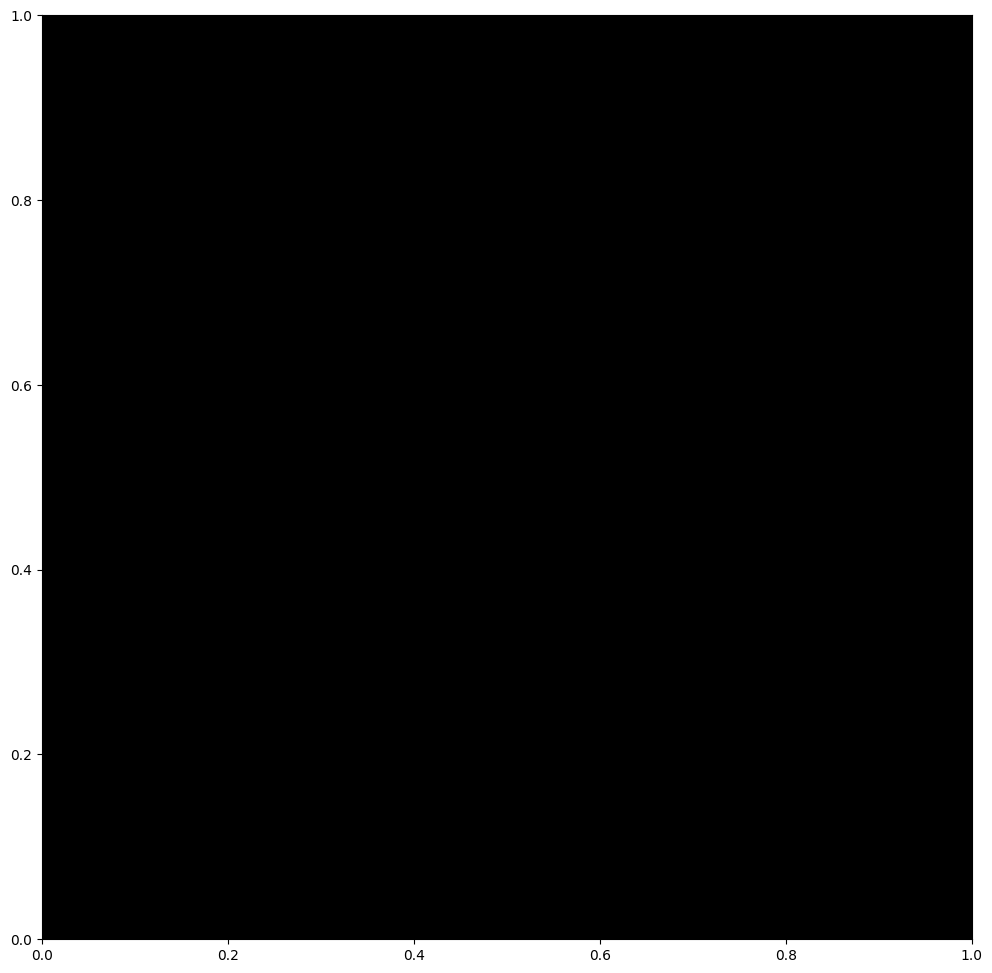

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12,12))
ax.set_facecolor("black")
sc = ax.scatter(df["lon"], df["lat"], c=df["oil_probability"], cmap="RdYlGn_r", s=15, marker="s")
plt.colorbar(sc, label="Oil probability")
ax.set_title("Kochi Scene — Oil Probability Heatmap")
plt.savefig("/content/heatmap.png", dpi=150, bbox_inches="tight")
print("Saved")

In [10]:
try:
    print("df exists, rows:", len(df))
    print("oil_only exists, rows:", len(oil_only))
except NameError as e:
    print("Missing:", e)

Missing: name 'df' is not defined


In [11]:
import os
path = "/content/kochi_detections.csv"
print("Exists in Colab temp storage?", os.path.exists(path))

Exists in Colab temp storage? False


In [14]:
# Reconnect Drive
from google.colab import drive
drive.mount("/content/drive")

# Reload model
import torch, torch.nn as nn
from torchvision import models, transforms
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.efficientnet_b0(weights=None)
model.classifier = nn.Sequential(nn.Linear(1280,128), nn.ReLU(), nn.Dropout(0.3), nn.Linear(128,2))
checkpoint = torch.load("/content/drive/MyDrive/Downloads/oil_spill_efficientnet_b0.pth", map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(device)
model.eval()
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
eval_tfms = transforms.Compose([transforms.Resize((224,224)), transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)])

# Re-extract the scene
import zipfile, os, re
ZIP_PATH = "/content/drive/MyDrive/Downloads/S1A_IW_GRDH_1SDV_20250528T004137_20250528T004157_059387_075F14_1A66.zip"
with zipfile.ZipFile(ZIP_PATH, "r") as z:
    names = z.namelist()
    manifest_name = [n for n in names if n.endswith("manifest.safe")][0]
    vv_tiffs = [n for n in names if n.endswith(".tiff") and "measurement" in n and "vv" in n.lower()]
    os.makedirs("/content/scene", exist_ok=True)
    z.extract(manifest_name, "/content/scene")
    z.extract(vv_tiffs[0], "/content/scene")
    MANIFEST_PATH = "/content/scene/" + manifest_name
    TIFF_PATH = "/content/scene/" + vv_tiffs[0]

with open(MANIFEST_PATH, "r") as f:
    manifest_text = f.read()
start_time = re.search(r"<safe:startTime>(.*?)</safe:startTime>", manifest_text).group(1)
coords_match = re.search(r"<gml:coordinates>(.*?)</gml:coordinates>", manifest_text).group(1)
corners = [tuple(map(float, pair.split(","))) for pair in coords_match.strip().split(" ")]

# Tile + predict
import rasterio, numpy as np, pandas as pd
from PIL import Image
import torch.nn.functional as F

CHIP_DIR = "/content/scene_chips"
os.makedirs(CHIP_DIR, exist_ok=True)
CHIP_SIZE = 400

with rasterio.open(TIFF_PATH) as src:
    width, height = src.width, src.height
    chip_records = []
    chip_id = 0
    for row in range(0, height - CHIP_SIZE, CHIP_SIZE):
        for col in range(0, width - CHIP_SIZE, CHIP_SIZE):
            window = rasterio.windows.Window(col, row, CHIP_SIZE, CHIP_SIZE)
            tile = src.read(1, window=window)
            if np.count_nonzero(tile) < (CHIP_SIZE * CHIP_SIZE * 0.5):
                continue
            lo, hi = np.percentile(tile, (2, 98))
            stretched = np.clip((tile - lo) / (hi - lo + 1e-6) * 255, 0, 255).astype(np.uint8)
            fname = f"chip_{chip_id:04d}.png"
            Image.fromarray(stretched).save(os.path.join(CHIP_DIR, fname))
            frac_row, frac_col = (row + CHIP_SIZE/2) / height, (col + CHIP_SIZE/2) / width
            lat = (corners[0][0]*(1-frac_row) + corners[3][0]*frac_row) * (1-frac_col) + (corners[1][0]*(1-frac_row) + corners[2][0]*frac_row) * frac_col
            lon = (corners[0][1]*(1-frac_row) + corners[3][1]*frac_row) * (1-frac_col) + (corners[1][1]*(1-frac_row) + corners[2][1]*frac_row) * frac_col
            chip_records.append({"chip_id": fname, "lat": round(lat,5), "lon": round(lon,5)})
            chip_id += 1

model.eval()
detections = []
for rec in chip_records:
    img = Image.open(os.path.join(CHIP_DIR, rec["chip_id"])).convert("RGB")
    x = eval_tfms(img).unsqueeze(0).to(device)
    with torch.no_grad():
        p_oil = F.softmax(model(x), dim=1)[0,1].item()
    detections.append({**rec, "timestamp_utc": start_time, "oil_probability": round(p_oil,4), "predicted_label": "oil" if p_oil>=0.5 else "no_oil"})

df = pd.DataFrame(detections)
# SAVE TO DRIVE THIS TIME so it never gets lost again
df.to_csv("/content/drive/MyDrive/kochi_detections.csv", index=False)
oil_only = df[df["predicted_label"]=="oil"].copy()
print(f"DONE: {len(oil_only)} of {len(df)} tiles flagged as oil")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Downloads/S1A_IW_GRDH_1SDV_20250528T004137_20250528T004157_059387_075F14_1A66.zip'

In [15]:
import os
folder = "/content/drive/MyDrive/Downloads"
if os.path.exists(folder):
    print("Folder exists. Contents:")
    for f in os.listdir(folder):
        print(" -", f)
else:
    print("This folder doesn't exist at all")

Folder exists. Contents:
 - DOC-20260824-WA0012.pdf
 - Unit - 1 WATER TECHNOLOGY.pdf
 - Setting Up a Red Hat Enterprise Linux Server.zip
 - wp15630908-the-climber-wallpapers.jpg
 - rpmfusion-free-release-44.noarch.rpm
 - rpmfusion-nonfree-release-44.noarch.rpm
 - deepseek_train_colab.ipynb
 - jpg
 - jpg(1)
 - Deep_Learning_Fundamentals_Tarun_Negi.pdf
 - oil_spill_detector.ipynb
 - oil_spill_detector(1).ipynb
 - oil_spill_detector(2).ipynb
 - oil_spill_efficientnet_b0.pth
 - marine-oil-spill-platform-redesign.zip
 - Setting Up a Red Hat Enterprise Linux Server
 - CURRENT LEARNING AREA
 - marine-oil-spill-platform-redesign
 - Copy of S1A_IW_GRDH_1SDV_20250614T004918_20250614T004941_059635_07678A_F7B9.zip
 - S1A_IW_GRDH_1SDV_20250614T004918_20250614T004941_059635_07678A_F7B9.zip
 - Downloads
 - drift_engine(1).py


In [16]:
import os
nested = "/content/drive/MyDrive/Downloads/Downloads"
if os.path.exists(nested):
    print("Nested folder contents:")
    for f in os.listdir(nested):
        print(" -", f)
else:
    print("No nested Downloads folder")

Nested folder contents:
 - 2026-syllabus.pdf
 - DOC-20260824-WA0012.pdf
 - Unit - 1 WATER TECHNOLOGY.pdf
 - ME-26101 (FME).pdf
 - Setting Up a Red Hat Enterprise Linux Server.zip
 - Complete_ML_Notes_Tarun_Negi.pdf
 - Complete_ML_Notes_Tarun_Negi-1.pdf
 - Deep_Learning_Fundamentals_Tarun_Negi.pdf
 - oil_spill_efficientnet_b0.pth
 - S1A_IW_GRDH_1SDV_20250614T004918_20250614T004941_059635_07678A_F7B9.zip
 - S1A_IW_GRDH_1SDV_20250528T004137_20250528T004157_059387_075F14_1A66.zip
 - CURRENT LEARNING AREA
 - marine-oil-spill-platform-redesign
 - Setting Up a Red Hat Enterprise Linux Server
 - deepseek_train_colab.ipynb
 - jpg
 - jpg(1)
 - oil_spill_detector.ipynb
 - oil_spill_detector(2).ipynb
 - rpmfusion-free-release-44.noarch.rpm
 - rpmfusion-nonfree-release-44.noarch.rpm
 - oil_spill_detector(1).ipynb
 - marine-oil-spill-platform-redesign.zip
 - wp15630908-the-climber-wallpapers.jpg


In [17]:
ZIP_PATH = "/content/drive/MyDrive/Downloads/S1A_IW_GRDH_1SDV_20250614T004918_20250614T004941_059635_07678A_F7B9.zip"


In [18]:
ZIP_PATH = "/content/drive/MyDrive/Downloads/Downloads/S1A_IW_GRDH_1SDV_20250528T004137_20250528T004157_059387_075F14_1A66.zip"

In [19]:
# Reconnect Drive
from google.colab import drive
drive.mount("/content/drive")

# Reload model
import torch, torch.nn as nn
from torchvision import models, transforms
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.efficientnet_b0(weights=None)
model.classifier = nn.Sequential(nn.Linear(1280,128), nn.ReLU(), nn.Dropout(0.3), nn.Linear(128,2))
checkpoint = torch.load("/content/drive/MyDrive/oil_spill_efficientnet_b0.pth", map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(device)
model.eval()
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
eval_tfms = transforms.Compose([transforms.Resize((224,224)), transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)])

# Re-extract the scene (CORRECTED PATH)
import zipfile, os, re
ZIP_PATH = "/content/drive/MyDrive/Downloads/Downloads/S1A_IW_GRDH_1SDV_20250528T004137_20250528T004157_059387_075F14_1A66.zip"
with zipfile.ZipFile(ZIP_PATH, "r") as z:
    names = z.namelist()
    manifest_name = [n for n in names if n.endswith("manifest.safe")][0]
    vv_tiffs = [n for n in names if n.endswith(".tiff") and "measurement" in n and "vv" in n.lower()]
    os.makedirs("/content/scene", exist_ok=True)
    z.extract(manifest_name, "/content/scene")
    z.extract(vv_tiffs[0], "/content/scene")
    MANIFEST_PATH = "/content/scene/" + manifest_name
    TIFF_PATH = "/content/scene/" + vv_tiffs[0]

with open(MANIFEST_PATH, "r") as f:
    manifest_text = f.read()
start_time = re.search(r"<safe:startTime>(.*?)</safe:startTime>", manifest_text).group(1)
coords_match = re.search(r"<gml:coordinates>(.*?)</gml:coordinates>", manifest_text).group(1)
corners = [tuple(map(float, pair.split(","))) for pair in coords_match.strip().split(" ")]

# Tile + predict
import rasterio, numpy as np, pandas as pd
from PIL import Image
import torch.nn.functional as F

CHIP_DIR = "/content/scene_chips"
os.makedirs(CHIP_DIR, exist_ok=True)
CHIP_SIZE = 400

with rasterio.open(TIFF_PATH) as src:
    width, height = src.width, src.height
    chip_records = []
    chip_id = 0
    for row in range(0, height - CHIP_SIZE, CHIP_SIZE):
        for col in range(0, width - CHIP_SIZE, CHIP_SIZE):
            window = rasterio.windows.Window(col, row, CHIP_SIZE, CHIP_SIZE)
            tile = src.read(1, window=window)
            if np.count_nonzero(tile) < (CHIP_SIZE * CHIP_SIZE * 0.5):
                continue
            lo, hi = np.percentile(tile, (2, 98))
            stretched = np.clip((tile - lo) / (hi - lo + 1e-6) * 255, 0, 255).astype(np.uint8)
            fname = f"chip_{chip_id:04d}.png"
            Image.fromarray(stretched).save(os.path.join(CHIP_DIR, fname))
            frac_row, frac_col = (row + CHIP_SIZE/2) / height, (col + CHIP_SIZE/2) / width
            lat = (corners[0][0]*(1-frac_row) + corners[3][0]*frac_row) * (1-frac_col) + (corners[1][0]*(1-frac_row) + corners[2][0]*frac_row) * frac_col
            lon = (corners[0][1]*(1-frac_row) + corners[3][1]*frac_row) * (1-frac_col) + (corners[1][1]*(1-frac_row) + corners[2][1]*frac_row) * frac_col
            chip_records.append({"chip_id": fname, "lat": round(lat,5), "lon": round(lon,5)})
            chip_id += 1

model.eval()
detections = []
for rec in chip_records:
    img = Image.open(os.path.join(CHIP_DIR, rec["chip_id"])).convert("RGB")
    x = eval_tfms(img).unsqueeze(0).to(device)
    with torch.no_grad():
        p_oil = F.softmax(model(x), dim=1)[0,1].item()
    detections.append({**rec, "timestamp_utc": start_time, "oil_probability": round(p_oil,4), "predicted_label": "oil" if p_oil>=0.5 else "no_oil"})

df = pd.DataFrame(detections)
df.to_csv("/content/drive/MyDrive/kochi_detections.csv", index=False)
oil_only = df[df["predicted_label"]=="oil"].copy()
print(f"DONE: {len(oil_only)} of {len(df)} tiles flagged as oil")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DONE: 124 of 1931 tiles flagged as oil


Saved


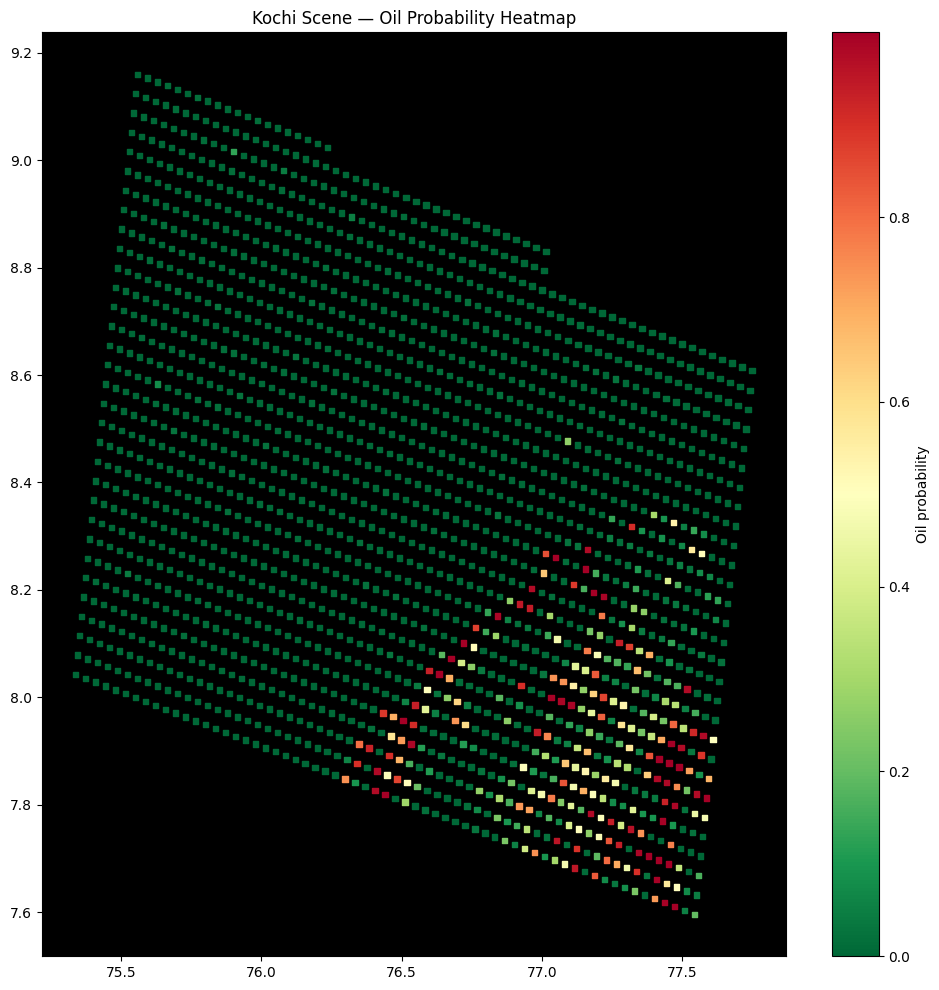

In [20]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12,12))
ax.set_facecolor("black")
sc = ax.scatter(df["lon"], df["lat"], c=df["oil_probability"], cmap="RdYlGn_r", s=15, marker="s")
plt.colorbar(sc, label="Oil probability")
ax.set_title("Kochi Scene — Oil Probability Heatmap")
plt.savefig("/content/heatmap.png", dpi=150, bbox_inches="tight")
print("Saved")

Saved


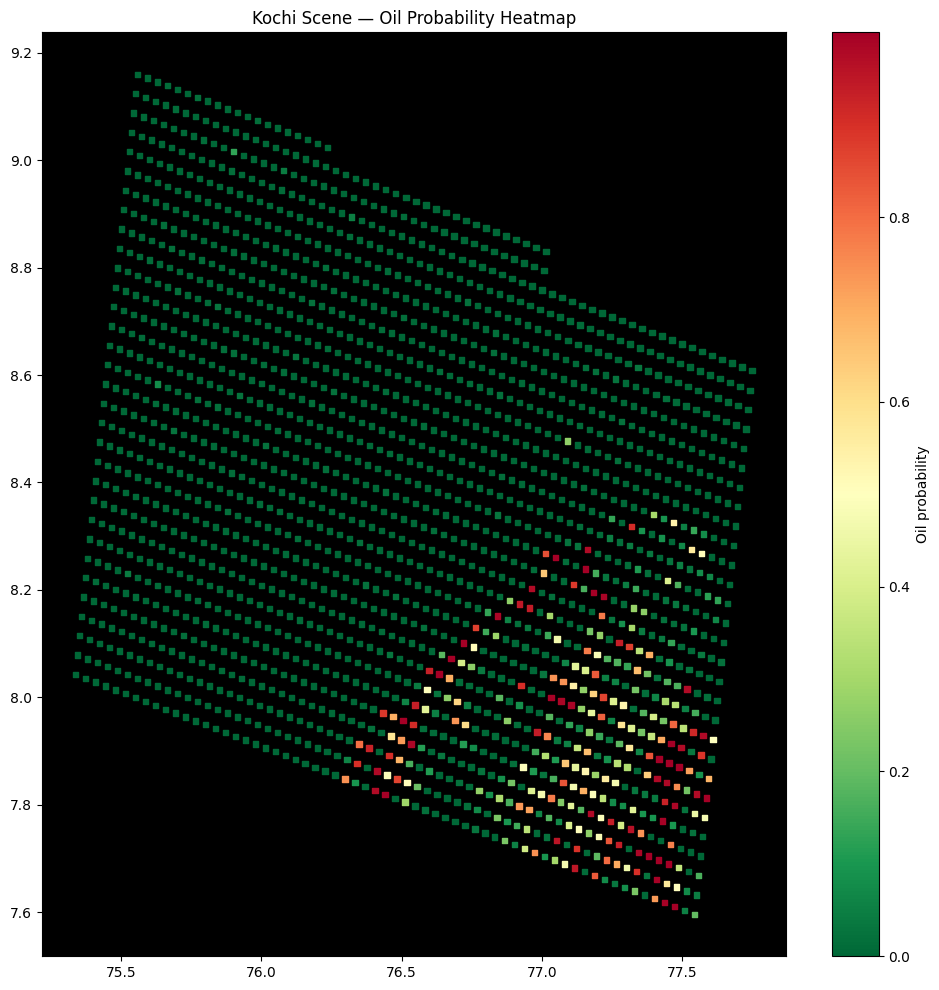

In [21]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12,12))
ax.set_facecolor("black")
sc = ax.scatter(df["lon"], df["lat"], c=df["oil_probability"], cmap="RdYlGn_r", s=15, marker="s")
plt.colorbar(sc, label="Oil probability")
ax.set_title("Kochi Scene — Oil Probability Heatmap")
plt.savefig("/content/heatmap.png", dpi=150, bbox_inches="tight")
print("Saved")

In [22]:
df.to_csv("/content/drive/MyDrive/kochi_detections.csv", index=False)  # save every tile's lat/lon/probability to Drive
print("Saved to Drive")  # confirm

Saved to Drive
